# 04 — STM em Folha de São Paulo (PT-BR)

**Corpus:** Folha de S. Paulo 2024 (subsample 5k, mesmo do LDA/NMF/BERTopic).
**Modelo:** STM (Roberts et al.) via R `stm` (`scripts/run_stm.R`), init Spectral (determinístico).
**Protocolo:** grid K por **C_v** (heldout/resíduos nativos como diagnóstico) → grid `sigma.prior` × `gamma.prior` → treino final + `estimateEffect` (efeitos de prevalência das covariáveis `date` + `category`).

Requer R no PATH com pacotes `stm`, `jsonlite`, `glmnet` (ver CLAUDE.md).


## 1. Setup e imports

Carregamos parâmetros do `configs/params.yaml` (entrada `corpora.folha`), o seed global e as funções dos pipelines reusáveis:

- `_helpers.lemmatize_corpus(docs, lang, params, model_key="stm")` → tokens lematizados + Dictionary com filter_extremes (bloco `stm:`)
- `_helpers.prepare_stm_input / grid_search_k_stm / grid_search_stm_hparams / train_stm` → monta o input, grid de K por C_v, grid `sigma.prior` × `gamma.prior` e treino final via R (`scripts/run_stm.R`), devolvendo theta/beta/efeitos
- `_helpers.name_all_topics` → rotulagem via Ollama (modelo em `params.yaml`)
- `_helpers.*` → métricas (c_v, exclusivity, FREX, etc.) — compartilhadas com o LDA/NMF


In [1]:
# ── path fix: resolve _helpers.py e data/ de qualquer subdiretório ──
import sys as _sys, os as _os
from pathlib import Path as _P
_here = _P().resolve()
_nb_dir = _here if (_here / '_helpers.py').exists() else _here.parent
if str(_nb_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_dir))
_os.chdir(_nb_dir)          # '../data/...' paths ficam corretos
del _here, _nb_dir, _P, _sys, _os
# ─────────────────────────────────────────────────────────────────────
# Cell 1 — Imports
import sys, os, json, time, ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

from _helpers import load_params, get_corpus_config, get_seed, load_corpus
from _helpers import lemmatize_corpus
from _helpers import (
    prepare_stm_input, grid_search_k_stm, grid_search_stm_hparams, train_stm,
    qualitative_report,
)
from _helpers import name_all_topics, name_topic
from _helpers import (
    compute_coherence_cv, compute_exclusivity, compute_exclusivity_ctfidf, compute_diversity,
    compute_topic_diversity, compute_frex_score, compute_stability,
    export_results, export_topics_for_eval,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


D:\Área de Trabalho\UPE\1 Período\PLN\Topic Modeling - LDA and BERTopic\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 2 — Carrega params do params.yaml
CORPUS_ID = "folha"
LANG = "pt"

params = load_params()
_, cfg = get_corpus_config(params, CORPUS_ID)
seed = get_seed(params)
TEXT_COL = cfg["text_column"]
PREV_FORMULA = cfg.get("stm_prevalence_formula", "") or ""
MIN_TOKENS = int(cfg.get("stm_min_tokens_per_doc", 0) or 0)
assert PREV_FORMULA, "stm_prevalence_formula vazia no params.yaml — defina a fórmula do corpus"

print(f"corpus_id = {CORPUS_ID}")
print(f"text_column = {TEXT_COL}")
print(f"language = {LANG}")
print(f"seed = {seed}")
print(f"covariates = {cfg.get('covariates', [])}")
print(f"prevalence_formula = {PREV_FORMULA}")
print(f"min_tokens_per_doc = {MIN_TOKENS}")


corpus_id = folha
text_column = message
language = pt
seed = 42
covariates = ['date', 'category']
prevalence_formula = ~ s(as.numeric(as.Date(date))) + category
min_tokens_per_doc = 200


## 2. Corpus Folha de São Paulo

### Origem e schema
- **Fonte:** CSV em `data/raw/folha/`
- **Idioma:** PT-BR, formal/jornalístico, 2018-2024
- **Schema:** `post_id`, `message`, `date`, `category` (editoria)




In [3]:
# Cell 3 — Carrega corpus_limpo.csv
# Resolve o corpus direto do output do 01-preprocessing (latest-wins, sem copia)
from _helpers import resolve_latest_dir
_corpus_dir = resolve_latest_dir(
    f"../../01-preprocessing/data/output/{CORPUS_ID}",
    contains="corpus_limpo.csv",
    fallback_dir=f"../data/input/{CORPUS_ID}",
)
CORPUS_VERSION = _corpus_dir.name
print(f"Versao do corpus: {CORPUS_VERSION}")
df = load_corpus(_corpus_dir)

# Subsample 5k (mesma seed=42 do BERTopic/LDA/NMF — mesmo conjunto de docs)
_s_idx = np.random.RandomState(42).choice(len(df), min(5000, len(df)), replace=False)
df = df.iloc[_s_idx].reset_index(drop=True)

# Covariáveis do STM não podem ter NA (matriz de desenho do stm/estimateEffect)
_cov_cols = [cfg.get("date_column", "data") if c == "date" else c for c in cfg.get("covariates", [])]
_n0 = len(df)
df = df.dropna(subset=_cov_cols).reset_index(drop=True)
print(f"Docs removidos por covariável NA: {_n0 - len(df)}")

# Filtro de tamanho mínimo (tokens brutos) — STM degrada com docs muito curtos
_n_raw = df[TEXT_COL].astype(str).str.split().str.len()
_n0 = len(df)
df = df[_n_raw >= MIN_TOKENS].reset_index(drop=True)
print(f"Docs removidos por < {MIN_TOKENS} tokens: {_n0 - len(df)}")

docs = df[TEXT_COL].astype(str).tolist()
post_ids = df["post_id"].astype(str).tolist()
print(f"Total docs: {len(docs):,}")
print(f"Colunas: {list(df.columns)}")
df.head(3)


  versão resolvida: folha_20260628_185652/ (latest)
Versao do corpus: folha_20260628_185652


Carregado: corpus_limpo.csv (4939 docs, SEM coluna 'sentiment' — rode 03-sentiment antes para ter cruzamento topic x sentiment automatico)
Docs removidos por covariável NA: 1


Docs removidos por < 200 tokens: 86
Total docs: 4,852
Colunas: ['post_id', 'message', 'message_raw', 'title', 'data', 'category', 'platform']


,post_id,message,message_raw,title,data,category,platform
0,post_1972,A China se prepara para vacinar crianças a par...,A China se prepara para vacinar crianças a par...,China pretende aplicar a vacina Coronavac em c...,2021-06-09 13:15:00.0000000,equilibrioesaude,folha_uol
1,post_4567,Quatro meses antes de deixar prescrever um pro...,Quatro meses antes de deixar prescrever um pro...,Justiça deixou prescrever processo contra Edir...,2019-11-26 08:00:00.0000000,poder,folha_uol
2,post_2423,"Ao longo de três meses, colunistas e blogueiro...","Ao longo de três meses, colunistas e blogueiro...",Leitores dão sugestões de leitura para a quare...,2020-07-21 23:15:00.0000000,equilibrioesaude,folha_uol


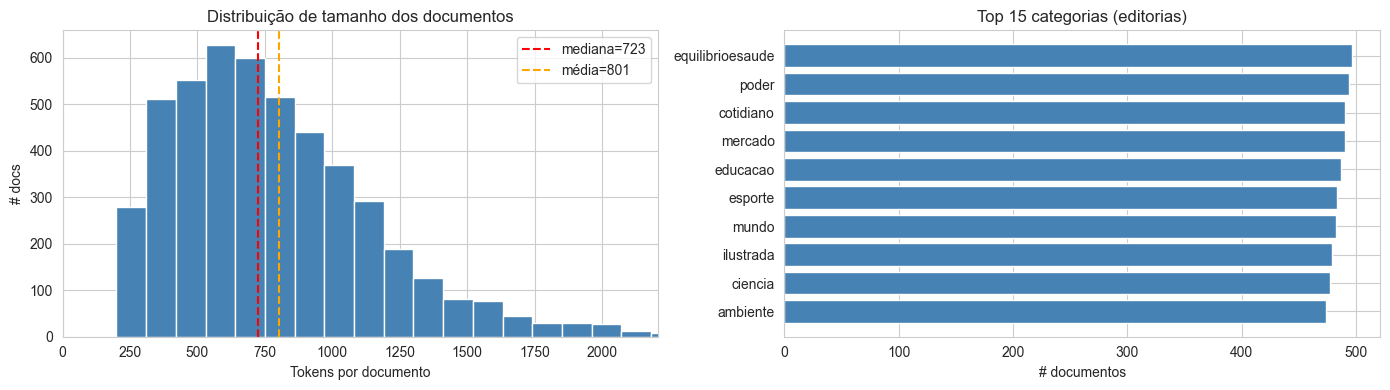


Descritivas n_tokens: {'count': 4852.0, 'mean': 801.4490931574609, 'std': 433.2433478772676, 'min': 200.0, '25%': 506.0, '50%': 723.0, '75%': 998.0, 'max': 6806.0}


In [4]:
# Cell 4 — Estatisticas descritivas + distribuicao de tokens
df["n_tokens"] = df["message"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["n_tokens"], bins=60, edgecolor="white", color="steelblue")
axes[0].axvline(df["n_tokens"].median(), color="red", linestyle="--", label=f'mediana={df["n_tokens"].median():.0f}')
axes[0].axvline(df["n_tokens"].mean(), color="orange", linestyle="--", label=f'média={df["n_tokens"].mean():.0f}')
axes[0].set_xlabel("Tokens por documento"); axes[0].set_ylabel("# docs")
axes[0].set_title("Distribuição de tamanho dos documentos"); axes[0].legend()
axes[0].set_xlim(0, df["n_tokens"].quantile(0.99))

cat_counts = df["category"].value_counts().head(15)
axes[1].barh(cat_counts.index[::-1], cat_counts.values[::-1], color="steelblue")
axes[1].set_xlabel("# documentos"); axes[1].set_title("Top 15 categorias (editorias)")
plt.tight_layout(); plt.show()

print(f"\nDescritivas n_tokens: {df['n_tokens'].describe().to_dict()}")


## 3. Lematização e construção do vocabulário

### O que `_helpers.lemmatize_corpus` faz

1. Carrega spaCy `pt_core_news_lg` (cached em module-level)
2. Para cada doc: tokeniza, descarta stopwords (lista interna spaCy) + tokens não-alfa + tokens curtos (`len(lemma) <= 2`)
3. Constrói gensim `Dictionary` com `filter_extremes(no_below=5, no_above=0.5)` (parâmetros do bloco `stm:` em `params.yaml`, via `model_key="stm"`):
   - Remove palavras que aparecem em <5 docs (raras, ruído)
   - Remove palavras em >50% dos docs (genéricas, sem poder discriminante — ex.: "disse")

### Por que lematizar (vs stemming)

- Lematização preserva forma legível (`correndo` → `correr`; stemming agressivo produziria `corr`)
- Mais interpretável para a banca da dissertação
- Custo: ~30s a ~3min em CPU dependendo do volume
- Mesmo vocabulário do LDA (mesmos `no_below`/`no_above`) — garante comparabilidade direta entre os dois modelos


In [5]:
# Cell 5 — Lematiza corpus
print("Lematizando (single-process spaCy pt_core_news_lg)...")
t0 = time.time()
tokenized, dictionary = lemmatize_corpus(docs, LANG, params, model_key="stm")
print(f"  done em {time.time()-t0:.0f}s")
print(f"  vocab final: {len(dictionary):,} palavras (após filter_extremes)")

# Estatísticas dos tokens lemmatizados
n_tokens_lemma = [len(t) for t in tokenized]
n_unique = [len(set(t)) for t in tokenized]

print(f"\n  avg tokens/doc após lemmatize: {np.mean(n_tokens_lemma):.1f}")
print(f"  avg unique tokens/doc: {np.mean(n_unique):.1f}")


Lematizando (single-process spaCy pt_core_news_lg)...


  done em 504s
  vocab final: 17,290 palavras (após filter_extremes)

  avg tokens/doc após lemmatize: 382.7
  avg unique tokens/doc: 243.8


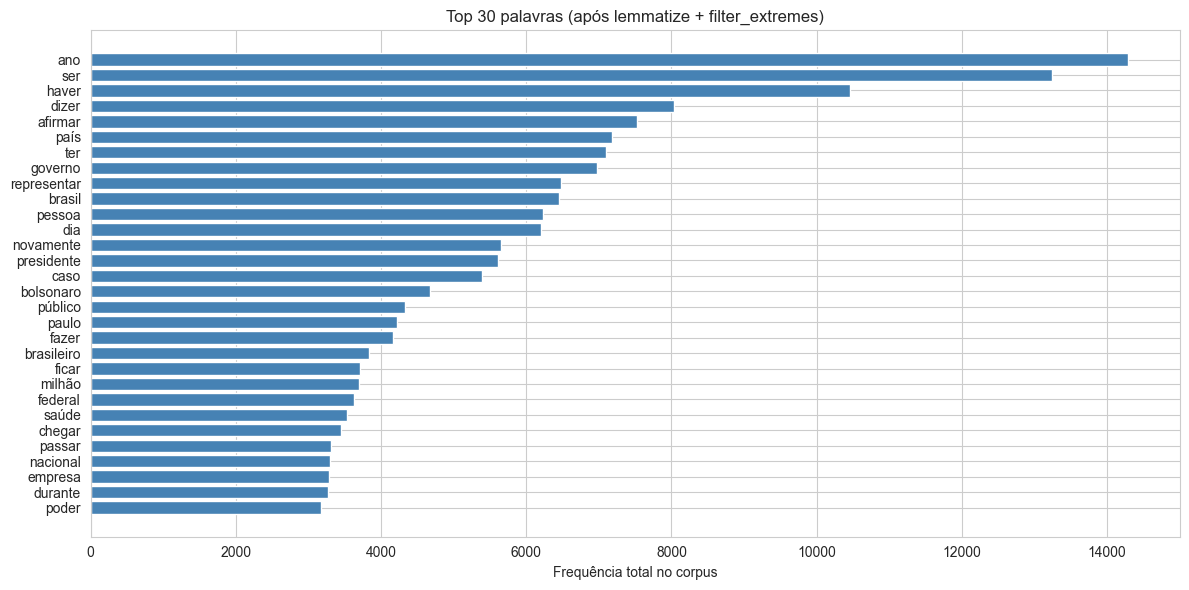

In [6]:
# Cell 6 — Top 30 palavras mais frequentes no vocabulário final
all_tokens = [t for doc in tokenized for t in doc]
freq = Counter(all_tokens)
top30 = freq.most_common(30)

fig, ax = plt.subplots(figsize=(12, 6))
words, counts = zip(*top30)
ax.barh(words[::-1], counts[::-1], color="steelblue")
ax.set_xlabel("Frequência total no corpus")
ax.set_title("Top 30 palavras (após lemmatize + filter_extremes)")
plt.tight_layout(); plt.show()


In [7]:
# Cell 7 — Input do STM: texto lematizado + covariáveis (mesmo vocab do C_v)
stm_df = prepare_stm_input(
    df, tokenized,
    covariates=cfg.get("covariates", []),
    date_col=cfg.get("date_column", "data"),
)
print(f"stm_input: {len(stm_df):,} docs | colunas: {stm_df.columns.tolist()}")
stm_df.head(3)


stm_input: 4,852 docs | colunas: ['text', 'post_id', 'date', 'category']


,text,post_id,date,category
0,china preparar vacinar criança ano idade covid...,post_1972,2021-06-09 13:15:00.0000000,equilibrioesaude
1,deixar prescrever processo criminal edir maced...,post_4567,2019-11-26 08:00:00.0000000,poder
2,longo colunista blogueiro dar sugestão período...,post_2423,2020-07-21 23:15:00.0000000,equilibrioesaude


## 4. Seleção de K (número de tópicos)

### Por que K importa

K é o **único hiperparâmetro estrutural** do STM (assim como no LDA). Influencia a granularidade dos tópicos:
- K muito baixo → tópicos macro/genéricos (varios temas misturados em um)
- K muito alto → fragmentação (mesmo tema dividido em múltiplos clusters)

### Como escolher

Mesmo protocolo do LDA: rodar STM em vários K, calcular **c_v coherence** (Roder et al. 2015) — métrica que combina:
- co-ocorrência das top-N palavras numa janela deslizante
- score NPMI normalizado
- agregação via cosine similarity

Limitação conhecida: **c_v penaliza K alto** (Stevens et al. 2012). Por isso complementamos com inspeção qualitativa em múltiplos K (próxima célula). Diferente do LDA, `gensim.models.STM` não expõe `log_perplexity` — não há métrica de perplexidade complementar aqui.


In [8]:
# Cell 8 — Grid search K (carrega resultado pre-computado se existir)
from _helpers import make_run_output_dir
# Subpasta stm/ separa runs por modelo (espelha lda/nmf/bertopic)
BASE_OUTPUT_DIR = Path(f"../data/output/{CORPUS_ID}/stm")
BASE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Saida carimbada por execucao: <corpus>_<data>_<hora> (nao sobrescreve runs anteriores)
OUTPUT_DIR = make_run_output_dir(BASE_OUTPUT_DIR, CORPUS_ID)
out_dir = str(OUTPUT_DIR)
# Caches do grid: vivem no diretorio-BASE stm/ (reutilizados entre runs)
m_path = f"{BASE_OUTPUT_DIR}/stm_metrics.csv"
diag_path = f"{BASE_OUTPUT_DIR}/stm_grid_k_diagnostics.csv"

if os.path.exists(m_path):
    m = pd.read_csv(m_path)
    scores = ast.literal_eval(m.iloc[0]["k_grid_scores"])
    scores = {int(k): float(v) for k, v in scores.items()}
    diag_df = pd.read_csv(diag_path) if os.path.exists(diag_path) else pd.DataFrame()
    print(f"Carregado grid pre-computado de {m_path}")
    print(f"  K range: {sorted(scores.keys())}")
elif os.path.exists(diag_path):
    # Fallback: grid ja rodou (diagnosticos salvos) mas o export final — que
    # grava stm_metrics.csv — ainda nao; reconstroi os C_v sem refazer os fits
    diag_df = pd.read_csv(diag_path)
    scores = {int(k): float(v) for k, v in zip(diag_df["k"], diag_df["cv"])}
    print(f"Grid K reconstruido do cache de diagnosticos ({diag_path})")
    print(f"  K range: {sorted(scores.keys())}")
elif cfg.get("stm_best_k"):
    # Grid K desligado — K pinado no params.yaml (corpus ja calibrado)
    scores, diag_df = {}, pd.DataFrame()
    print(f"Grid K desligado — stm_best_k={cfg['stm_best_k']} pinado no params.yaml (sem cache para plotar)")
else:
    K_RANGE = [3, 5, 7, 8, 10, 12, 15, 20, 25, 30]
    print(f"Rodando grid K em {K_RANGE} (1 fit STM/R por K, split heldout)...")
    scores, diag_df = grid_search_k_stm(
        stm_df, tokenized, dictionary, K_RANGE, PREV_FORMULA, params["stm"],
        work_dir=out_dir, seed=seed, top_n=params["evaluation"]["top_n_keywords"],
    )
    diag_df.to_csv(diag_path, index=False)
    print("Done.")

scores


Carregado grid pre-computado de ..\data\output\folha\stm/stm_metrics.csv
  K range: [3, 5, 7, 8, 10, 12, 15, 20, 25, 30]


{3: 0.48900140830414923,
 5: 0.5101607189182198,
 7: 0.5934911134694344,
 8: 0.6538061937136443,
 10: 0.6440037607781856,
 12: 0.6504656509780083,
 15: 0.6618459651120874,
 20: 0.6731149273174172,
 25: 0.6774544080017959,
 30: 0.6680492902841355}

In [ ]:
# Cell 9 — C_v vs K + diagnósticos nativos do STM (heldout / resíduos)
if not scores:
    print("Grid K desligado (stm_best_k pinado) e sem cache — nada a plotar.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    ks = sorted(scores)
    vs = [scores[k] for k in ks]

    ax = axes[0]
    ax.plot(ks, vs, marker="o", linewidth=2.5, markersize=9, color="steelblue", label="C_v")
    ax.fill_between(ks, vs, alpha=0.1, color="steelblue")
    peak_k = max(scores, key=scores.get)
    ax.axvline(peak_k, color="red", linestyle="--", alpha=0.6, label=f"peak c_v: K={peak_k} ({scores[peak_k]:.3f})")
    for k, v in zip(ks, vs):
        delta = (v - scores[peak_k]) / scores[peak_k] * 100
        label = f"{v:.3f}" if k == peak_k else f"{v:.3f}\n({delta:+.0f}%)"
        ax.annotate(label, (k, v), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8)
    ax.set_xlabel("K (número de tópicos)"); ax.set_ylabel("c_v coherence", color="steelblue")
    ax.set_title(f"STM grid search — Folha de São Paulo ({len(docs):,} docs)")
    ax.legend(loc="lower right")

    ax2 = axes[1]
    if not diag_df.empty:
        ax2.plot(diag_df["k"], diag_df["heldout_likelihood"], marker="o", color="darkgreen", label="heldout likelihood")
        ax2.set_xlabel("K"); ax2.set_ylabel("heldout likelihood", color="darkgreen")
        ax2b = ax2.twinx()
        ax2b.plot(diag_df["k"], diag_df["residual_dispersion"], marker="s", color="firebrick", label="residual dispersion")
        ax2b.set_ylabel("residual dispersion", color="firebrick")
        ax2b.axhline(1.0, color="firebrick", linestyle=":", alpha=0.5)
        ax2.set_title("Diagnósticos nativos STM (apoio — nao decide; ver fronteira semcoh x exclus)")
    else:
        ax2.text(0.5, 0.5, "diagnostics não disponíveis\n(grid carregado de cache antigo)", ha="center", va="center")
        ax2.axis("off")
    plt.tight_layout()
    plt.savefig(BASE_OUTPUT_DIR / "stm_grid_k_diagnostics.png", dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Salvo: {BASE_OUTPUT_DIR / 'stm_grid_k_diagnostics.png'}")
    plt.show()

    print(f"\nPico de C_v (reporte, NAO decide — ver fronteira semcoh x exclus): K={peak_k} (c_v={scores[peak_k]:.4f})")
    if not diag_df.empty:
        print(diag_df.to_string(index=False))


In [ ]:
# Scatter semantic coherence x exclusivity por K (Roberts et al. — seleção de modelo STM)
# K escolhido pelo protocolo (2026-08-16, C6): fronteira de Pareto semantic_coherence x
# exclusivity_stm dentro da faixa declarada de K (FAIXA_K, _selecao.py), desempate = menor K.
# O C_v (argmax) segue marcado tambem, mas so como reporte — a divergencia entre os dois
# e informacao, nao erro (mesma logica de `_selecao.py selecionar stm <corpus>`).
from _selecao import _pareto, FAIXA_K

_diag_csv = BASE_OUTPUT_DIR / "stm_grid_k_diagnostics.csv"
if _diag_csv.exists():
    _d = pd.read_csv(_diag_csv)
    _k_min, _k_max = FAIXA_K[CORPUS_ID]
    _d_adm = _d[(_d["k"] >= _k_min) & (_d["k"] <= _k_max)]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(_d["semantic_coherence"], _d["exclusivity_stm"], s=90, color="steelblue", zorder=3)
    for _, r in _d.iterrows():
        marca = "" if _k_min <= r["k"] <= _k_max else " (fora da faixa)"
        ax.annotate(f"K={int(r['k'])}{marca}", (r["semantic_coherence"], r["exclusivity_stm"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=9)

    _melhor_cv = _d.loc[_d["cv"].idxmax()]
    ax.scatter([_melhor_cv["semantic_coherence"]], [_melhor_cv["exclusivity_stm"]], s=140,
               facecolors="none", edgecolors="gray", linewidths=1.5, zorder=4,
               label=f"melhor C_v (reporte, nao decide): K={int(_melhor_cv['k'])}")

    _fr = _pareto(_d_adm, ["semantic_coherence", "exclusivity_stm"]) if not _d_adm.empty else _d_adm
    if not _fr.empty:
        _escolhido = _fr.sort_values("k", ascending=True).iloc[0]
        ax.scatter([_escolhido["semantic_coherence"]], [_escolhido["exclusivity_stm"]], s=180,
                   facecolors="none", edgecolors="red", linewidths=2.5, zorder=5,
                   label=f"escolhido pelo protocolo (Pareto + menor K): K={int(_escolhido['k'])}")

    ax.set_xlabel("Coerência semântica (Mimno et al.)")
    ax.set_ylabel("Exclusividade (FREX médio)")
    ax.set_title(f"STM — fronteira coerência × exclusividade por K ({CORPUS_ID})")
    ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout()
    plt.savefig(BASE_OUTPUT_DIR / "stm_grid_semcoh_exclus.png", dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Salvo: {BASE_OUTPUT_DIR / 'stm_grid_semcoh_exclus.png'}")
    plt.show()
else:
    print("Sem stm_grid_k_diagnostics.csv — scatter pulado")

## 5. Inspeção qualitativa multi-K

Como `c_v` favorece K menor, precisamos olhar **os tópicos em si** para escolher K com critério metodológico (não só estatístico). Carregamos os tópicos de K=5, 7, 10, 15, 30 pré-computados em `stm_multi_k_inspect.csv`, se disponível (execução prévia opcional — ver célula abaixo).


In [11]:
# Categorias canônicas da Folha para validação
if 'category' in df.columns:
    cat_dist = df['category'].value_counts()
    print('Distribuicao de categorias:')
    print(cat_dist.to_string())
else:
    print('Coluna category nao encontrada — pular validacao por categoria')


Distribuicao de categorias:
category
equilibrioesaude    496
poder               494
cotidiano           490
mercado             490
educacao            487
esporte             483
mundo               482
ilustrada           479
ciencia             477
ambiente            474


## 6. Decisão de K e treino final

**Trade-off:** `c_v` favorece K pequeno. Combine com inspeção qualitativa. Ajuste `BEST_K` na célula abaixo se necessário.


In [ ]:
# Cell 12 — Grid sigma.prior × gamma.prior (K=BEST_K fixo) + treino final
# K por Pareto(semantic_coherence, exclusivity_stm) + menor K (protocolo 2026-08-16,
# secao 4.2.3) — NAO por argmax de C_v (o C_v segue so como reporte). Le direto do CSV
# de diagnosticos em disco para funcionar tanto no grid recem-rodado quanto num cache
# de execucao anterior (o `scores`/`diag_df` em memoria nem sempre cobrem os dois casos).
_pin_k = cfg.get("stm_best_k")
if _pin_k:
    BEST_K = int(_pin_k)
    print(f"BEST_K pinado no params.yaml: {BEST_K}")
else:
    from _selecao import _pareto, FAIXA_K
    _diag_csv_k = BASE_OUTPUT_DIR / "stm_grid_k_diagnostics.csv"
    BEST_K = None
    if _diag_csv_k.exists():
        _d_k = pd.read_csv(_diag_csv_k)
        _k_min, _k_max = FAIXA_K[CORPUS_ID]
        _adm_k = _d_k[(_d_k["k"] >= _k_min) & (_d_k["k"] <= _k_max)]
        _fr_k = _pareto(_adm_k, ["semantic_coherence", "exclusivity_stm"]) if not _adm_k.empty else _adm_k
        if not _fr_k.empty:
            BEST_K = int(_fr_k.sort_values("k", ascending=True).iloc[0]["k"])
    if BEST_K is None:
        BEST_K = max(scores, key=scores.get)
        print("!! sem stm_grid_k_diagnostics.csv utilizavel — caiu no argmax de C_v, FORA do protocolo.")
    print(f"BEST_K automático (fronteira semcoh x exclus, desempate = menor K): {BEST_K}")

_shp_cache = f"{BASE_OUTPUT_DIR}/stm_sigma_gamma_grid.csv"
_sigma_grid = params["evaluation"].get("stm_sigma_prior_grid", [0, 0.3, 0.5, 0.7])
_gamma_grid = params["evaluation"].get("stm_gamma_prior_grid", ["Pooled", "L1"])

_pin_sigma, _pin_gamma = cfg.get("stm_sigma_prior"), cfg.get("stm_gamma_prior")
if _pin_sigma is not None and _pin_gamma:
    # Grid sigma/gamma desligado — hiperparametros pinados no params.yaml
    shp_df = pd.DataFrame()
    best_sigma, best_gamma = float(_pin_sigma), str(_pin_gamma)
    print(f"Grid sigma/gamma desligado — pinado no params.yaml: sigma={best_sigma}, gamma={best_gamma!r}")
elif os.path.exists(_shp_cache):
    shp_df = pd.read_csv(_shp_cache)
    best_sigma = float(shp_df.iloc[0]["sigma_prior"])
    best_gamma = str(shp_df.iloc[0]["gamma_prior"])
    print(f"Grid sigma/gamma carregado do cache ({_shp_cache}).")
else:
    print(f"Grid sigma ({len(_sigma_grid)}) × gamma ({len(_gamma_grid)}) = {len(_sigma_grid)*len(_gamma_grid)} combos (1 fit R cada)...")
    t0 = time.time()
    shp_df, best_sigma, best_gamma = grid_search_stm_hparams(
        stm_df, tokenized, dictionary, BEST_K, PREV_FORMULA, params["stm"],
        work_dir=out_dir, sigma_grid=_sigma_grid, gamma_grid=_gamma_grid, seed=seed,
        top_n=params["evaluation"]["top_n_keywords"],
    )
    shp_df.to_csv(_shp_cache, index=False)
    print(f"  done em {time.time()-t0:.0f}s")

if not shp_df.empty:
    print(shp_df.to_string(index=False))
print(f"\n  ★ best_sigma={best_sigma!r}  best_gamma={best_gamma!r}")

# Heatmap C_v por sigma × gamma
if len(shp_df) > 1:
    _pivot = shp_df.pivot_table(index="sigma_prior", columns="gamma_prior", values="cv", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(7, max(3, len(_pivot) * 0.8 + 1)))
    sns.heatmap(_pivot, annot=True, fmt=".4f", cmap="RdYlGn", ax=ax, linewidths=0.5)
    ax.set_title(f"STM sigma.prior × gamma.prior (K={BEST_K}) — C_v (maior = melhor)")
    plt.tight_layout(); plt.show()

# Treino final com melhores hiperparâmetros
print(f"\nTreinando STM K={BEST_K}, sigma={best_sigma!r}, gamma={best_gamma!r} (Spectral, determinístico)...")
t0 = time.time()
keywords, keywords_frex, theta, beta_df, effects, stm_meta = train_stm(
    stm_df, BEST_K, PREV_FORMULA, params["stm"], work_dir=out_dir,
    sigma_prior=best_sigma, gamma_prior=best_gamma, seed=seed,
    top_n=params["evaluation"]["top_n_keywords"],
)
print(f"  done em {time.time()-t0:.0f}s ({stm_meta['iterations']} iterações EM)")

# Realinha docs com os removidos pelo prepDocuments do R (docs vazios pós-filtro)
_removed = set(stm_meta.get("docs_removed", []))
if _removed:
    _keep = [i for i in range(len(docs)) if i not in _removed]
    docs = [docs[i] for i in _keep]
    post_ids = [post_ids[i] for i in _keep]
    df = df.iloc[_keep].reset_index(drop=True)
    tokenized = [tokenized[i] for i in _keep]
    print(f"  {len(_removed)} docs removidos pelo prepDocuments do R (realinhados)")
assert theta.shape == (len(docs), BEST_K), (theta.shape, len(docs))

topics_keywords = keywords
dominant = theta.argmax(axis=1).tolist()
full = theta.tolist()
theta_arr = theta

top_n = params["evaluation"]["top_n_keywords"]
print(f"\nTopics (top-{top_n} por probabilidade | FREX entre colchetes):")
for tid in sorted(topics_keywords):
    print(f"  T{tid:2d}: {topics_keywords[tid]}")
    print(f"        FREX: {keywords_frex[tid]}")


## 7. Rotulagem via LLM (Ollama)

`_helpers.name_all_topics` envia as keywords pro modelo configurado em `params.yaml` (`llm.model`) via Ollama com prompt few-shot em PT-BR. Em ~9s/tópico em CPU. Fallback: top-3 keywords se Ollama indisponível.


In [13]:
# === Nomeação STM via LLM — pipeline melhorado ===
#
# Melhorias vs naming genérico anterior:
# - top_n_keywords_llm=50 (params.yaml; antes só 10 keywords passavam)
# - 3 docs representativos por probabilidade theta (antes: 0 docs)
# - Prompt PT-BR few-shot + anti-redundância + regra TEMA GERAL
# - Deduplicação pós-geração
# - Ordering por tamanho (maiores tópicos primeiro → nomes centrais primeiro)
# - /no_think removido (diretiva Qwen3; gemma2:2b ignora ou ecoa como texto)

llm_cfg = params.get("llm", {})
top_n_llm = params["evaluation"].get("top_n_keywords_llm", 50)

# ---- Extrai até top_n_llm keywords por tópico para o LLM ----
topics_keywords_llm = {
    tid: beta_df.loc[tid].nlargest(top_n_llm).index.tolist()
    for tid in range(BEST_K)
}

# ---- Docs representativos: 3 docs com maior probabilidade theta ----
# Computa distribuições inline se ainda não foram computadas
theta_arr = theta  # theta do train_stm (R); dominant ja computado no treino

N_REPR_DOCS_STM = 3

def _representative_docs_stm(tid, n=N_REPR_DOCS_STM):
    """3 docs com maior P(tópico|doc) para o tópico tid."""
    top_idx = np.argsort(theta_arr[:, tid])[::-1][:n]
    return [docs[i] for i in top_idx]

# ---- Prompt PT-BR com few-shot + anti-redundância ----
_FEW_SHOT_STM = """\
Exemplos de bom rótulo (frase nominal coerente):

  Palavras-chave: eleição, presidente, voto, urna, candidato, campanha
  Rótulo: Eleições presidenciais e campanha

  Palavras-chave: selic, juros, banco central, inflação, copom, mercado
  Rótulo: Política monetária e controle da inflação

  Palavras-chave: futebol, campeonato, time, jogador, gol, brasileirão
  Rótulo: Futebol e campeonato nacional

  Palavras-chave: stf, supremo, ministro, julgamento, lei, constituição
  Rótulo: Decisões do Supremo Tribunal Federal

  Palavras-chave: clima, chuva, temperatura, seca, enchente, alerta
  Rótulo: Eventos climáticos extremos no Brasil

  Palavras-chave: cinema, filme, série, streaming, roteiro, diretor
  Rótulo: Cinema, séries e produções audiovisuais

Exemplos de DOIS temas PRÓXIMOS nomeados de forma DISTINTA (faça assim):

  Palavras-chave: clima, emissões, energia, países, combustíveis, acordo
  Rótulo: Política climática e transição energética

  Palavras-chave: gelo, antártida, temperaturas, el niño, calor, degelo
  Rótulo: Aquecimento global e degelo polar

Exemplo de rótulo RUIM (NÃO faça assim):
  - "eleição, presidente, voto" (é LISTA de keywords, não rótulo)
"""


def _prompt_builder_stm(keywords, example_docs=None, assigned_names=None):
    keywords_str = ", ".join(keywords[:top_n_llm])
    avoid_block = ""
    if assigned_names:
        _listed = "\n".join(f"- {n}" for n in assigned_names)
        avoid_block = (
            "\nRÓTULOS já atribuídos (NÃO repita nem faça variação leve):\n"
            + _listed + "\n"
            "Se este tópico for parecido com algum acima, identifique o termo das "
            "palavras-chave que o DIFERENCIA e use-o no rótulo. NUNCA use sufixos "
            "como '(2)' ou '(gelo)'.\n\n"
        )
    docs_block = ""
    if example_docs:
        snippets = [
            f"[Documento {i + 1}]\n{d[:250].strip()}..."
            for i, d in enumerate(example_docs[:3])
        ]
        docs_block = "\n\nDocumentos representativos do tópico:\n" + "\n\n".join(snippets)
    return (
        "Você é um especialista em análise temática de notícias brasileiras.\n"
        "Crie um RÓTULO HUMANO LEGÍVEL (frase nominal PT-BR, 4-6 palavras).\n\n"
        + _FEW_SHOT_STM + "\n" + avoid_block
        + "Agora nomeie este tópico:\n\n"
        f"Palavras-chave: {keywords_str}{docs_block}\n\n"
        "Regras:\n"
        "- Uma única frase nominal coerente (4-6 palavras).\n"
        "- As PRIMEIRAS palavras-chave são as mais importantes (maior peso): baseie o rótulo nelas.\n"
        "- Se as palavras misturarem dois assuntos, nomeie o ASSUNTO DOMINANTE (o das primeiras palavras), não uma mistura vaga.\n"
        "- Nomeie o TEMA GERAL comum aos documentos, não um evento isolado.\n"
        "- Rótulo CLARAMENTE DISTINTO dos já listados (use o termo que diferencia este tópico).\n"
        "- Sem aspas, sem prefixo 'Rótulo:', sem explicações.\n"
        "- Capitalize apenas a primeira palavra.\n\nRótulo:"
    )


_system_prompt_stm = (
    "Você é um especialista em análise temática de notícias brasileiras. "
    "Responda SEMPRE em português brasileiro com uma frase nominal curta (4-6 palavras). "
    "NUNCA use listas de palavras-chave separadas por vírgula."
)


def _dedupe_name_stm(name, keywords, used_lower):
    """Garante unicidade: keyword distintiva ou sufixo numérico."""
    if name.lower() not in used_lower:
        return name
    for kw in keywords:
        if kw.lower() not in name.lower():
            cand = f"{name} ({kw})"
            if cand.lower() not in used_lower:
                return cand
    i = 2
    while f"{name} ({i})".lower() in used_lower:
        i += 1
    return f"{name} ({i})"


# ---- Ordering por tamanho do tópico ----
_topic_counts_stm = pd.Series(dominant).value_counts().to_dict()
_order_stm = sorted(range(BEST_K), key=lambda t: -_topic_counts_stm.get(t, 0))

_used_lower_stm: set = set()
_assigned_names_stm: list = []
names: dict = {}

naming_enabled = llm_cfg.get("enabled", True)
if naming_enabled:
    print(f"Nomeando {BEST_K} tópicos STM via LLM ({llm_cfg['model']})...")
    print(f"  top_n_llm={top_n_llm} | {N_REPR_DOCS_STM} docs por theta | anti-redundância: ativo | ordem: maior → menor\n")
    for tid in _order_stm:
        kws = topics_keywords_llm[tid]
        rep_docs = _representative_docs_stm(tid)

        def _pb(keywords, example_docs=None, _an=list(_assigned_names_stm)):
            return _prompt_builder_stm(keywords, example_docs, assigned_names=_an)

        t0 = time.time()
        name = name_topic(
            kws,
            model=llm_cfg["model"],
            base_url=llm_cfg.get("base_url", "http://localhost:11434"),
            example_docs=rep_docs,
            prompt_builder=_pb,
            system_prompt=_system_prompt_stm,
        )
        name = _dedupe_name_stm(name, kws, _used_lower_stm)
        _used_lower_stm.add(name.lower())
        _assigned_names_stm.append(name)
        names[tid] = name

        top3 = ", ".join(kws[:3])
        print(f"  T{tid:>2} ({_topic_counts_stm.get(tid, 0):>4} docs, {time.time() - t0:.1f}s): {name}")
        print(f"       [{top3}]")
else:
    print("LLM desabilitado — usando fallback top-3 keywords.")
    names = {tid: ", ".join(kws[:3]) for tid, kws in topics_keywords.items()}

names = {t: names.get(t, f"T{t}") for t in range(BEST_K)}
print(f"\n{BEST_K} tópicos nomeados.")


Nomeando 25 tópicos STM via LLM (gemma2:2b-instruct-q4_K_M)...
  top_n_llm=50 | 3 docs por theta | anti-redundância: ativo | ordem: maior → menor



  T 4 ( 344 docs, 38.0s): Eleições e governo federal
       [bolsonaro, presidente, lula]


  T 2 ( 323 docs, 3.1s): Educação no Brasil e ensino superior
       [educação, escola, aluno]


  T11 ( 287 docs, 3.2s): Desmatamento na Amazônia e governo
       [desmatamento, amazônia, indígena]


  T 1 ( 284 docs, 3.1s): Futebol e Seleção Brasileira
       [clube, copa, jogo]


...

  T17 ( 118 docs, 3.2s): Missões Espaciais e Lua
       [espacial, missão, lua]


  T 3 ( 115 docs, 3.3s): Olímpicos e campeonatos mundiais de esporte
       [atleta, esporte, jogos]


  T 8 ( 102 docs, 3.2s): Tecnologia e empresas no Brasil
       [empresa, seta, milhão]


  T24 (  67 docs, 3.3s): Fauna e conservação na Pantanal
       [animal, espécie, humano]


  T16 (  54 docs, 3.2s): Consumo e produção de alimentos no Brasil
       [água, alimento, produto]

25 tópicos nomeados.


## 8. Visualização dos tópicos

Wordclouds + bar charts mostram a estrutura semântica de cada tópico. Escala logarítmica destaca palavras menos frequentes mas igualmente representativas.


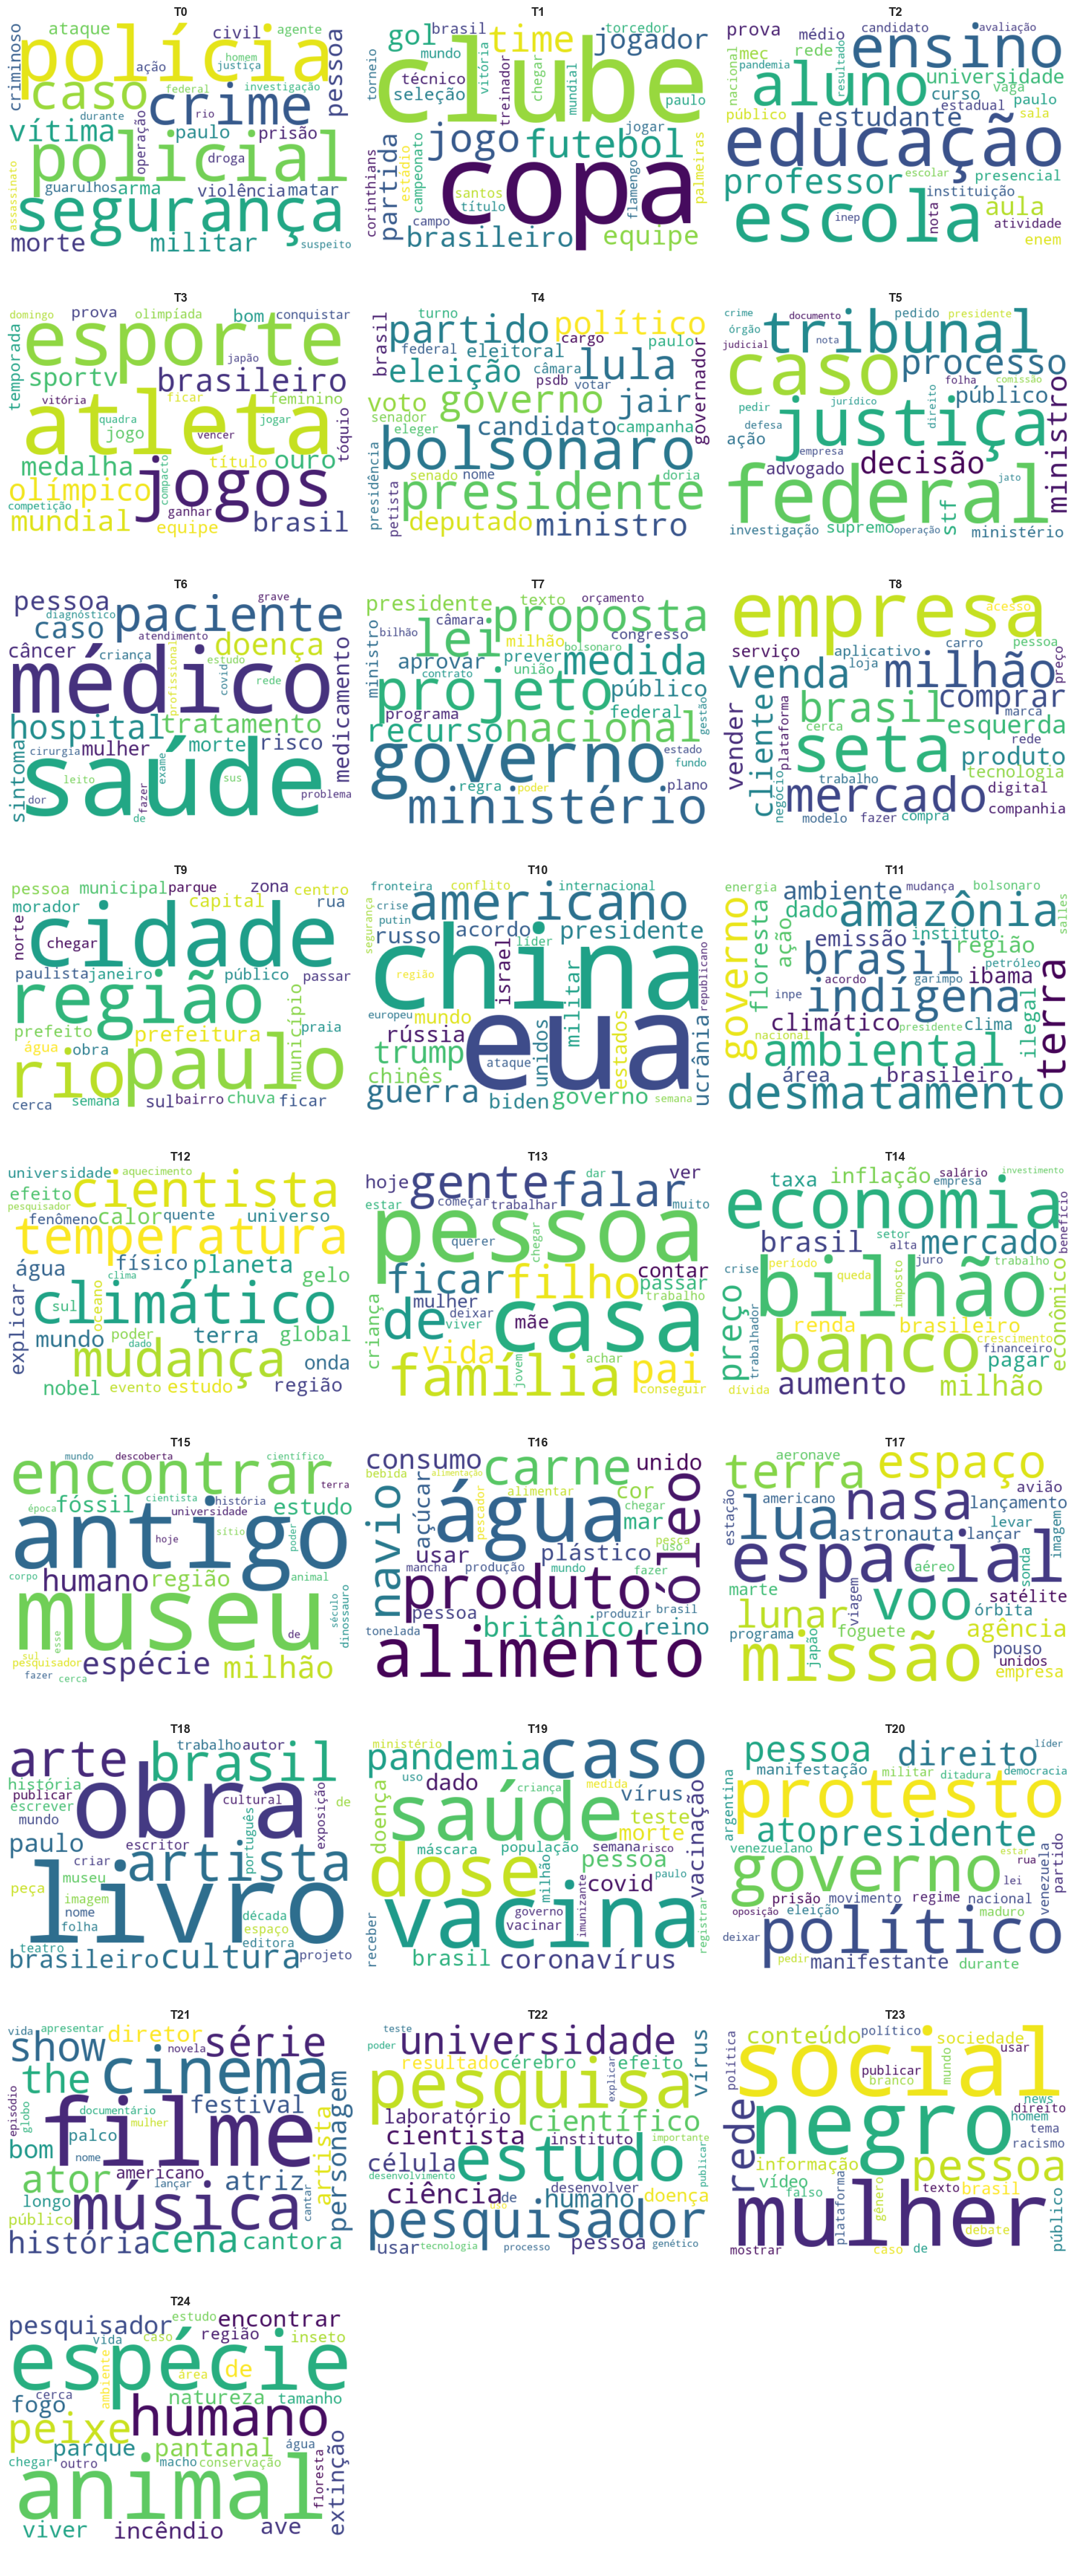

In [14]:
# Cell 13 — Wordclouds (1 por topico)
ncols = 3
nrows = (BEST_K + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten() if BEST_K > 1 else [axes]

_dead_topics = []
for tid in sorted(topics_keywords):
    # beta_df.loc[tid] = P(palavra|tópico) do STM; usa como frequência do wordcloud
    word_probs = beta_df.loc[tid].nlargest(30).to_dict()
    # topico "morto" (sem massa de probabilidade, comum com K alto): a linha
    # de beta pode conter NaN quando normaliza 0/0
    valid_probs = {w: p for w, p in word_probs.items() if np.isfinite(p) and p > 0}
    axes[tid].set_title(f"T{tid}", fontsize=12, fontweight="bold")
    axes[tid].axis("off")
    if not valid_probs:
        _dead_topics.append(tid)
        axes[tid].text(0.5, 0.5, "topico degenerado\n(sem massa de probabilidade)",
                       ha="center", va="center", fontsize=9, color="gray", wrap=True)
        continue
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap="viridis", max_words=30, prefer_horizontal=0.9).generate_from_frequencies(valid_probs)
    axes[tid].imshow(wc, interpolation="bilinear")

# Esconde axes nao usados
for i in range(BEST_K, len(axes)):
    axes[i].axis("off")

plt.tight_layout(); plt.show()

if _dead_topics:
    print(f"AVISO: {len(_dead_topics)} topico(s) degenerado(s) (sem massa de probabilidade): {_dead_topics}")
    print("  Indica K provavelmente alto demais para o vocabulario deste corpus — considere revisar BEST_K.")

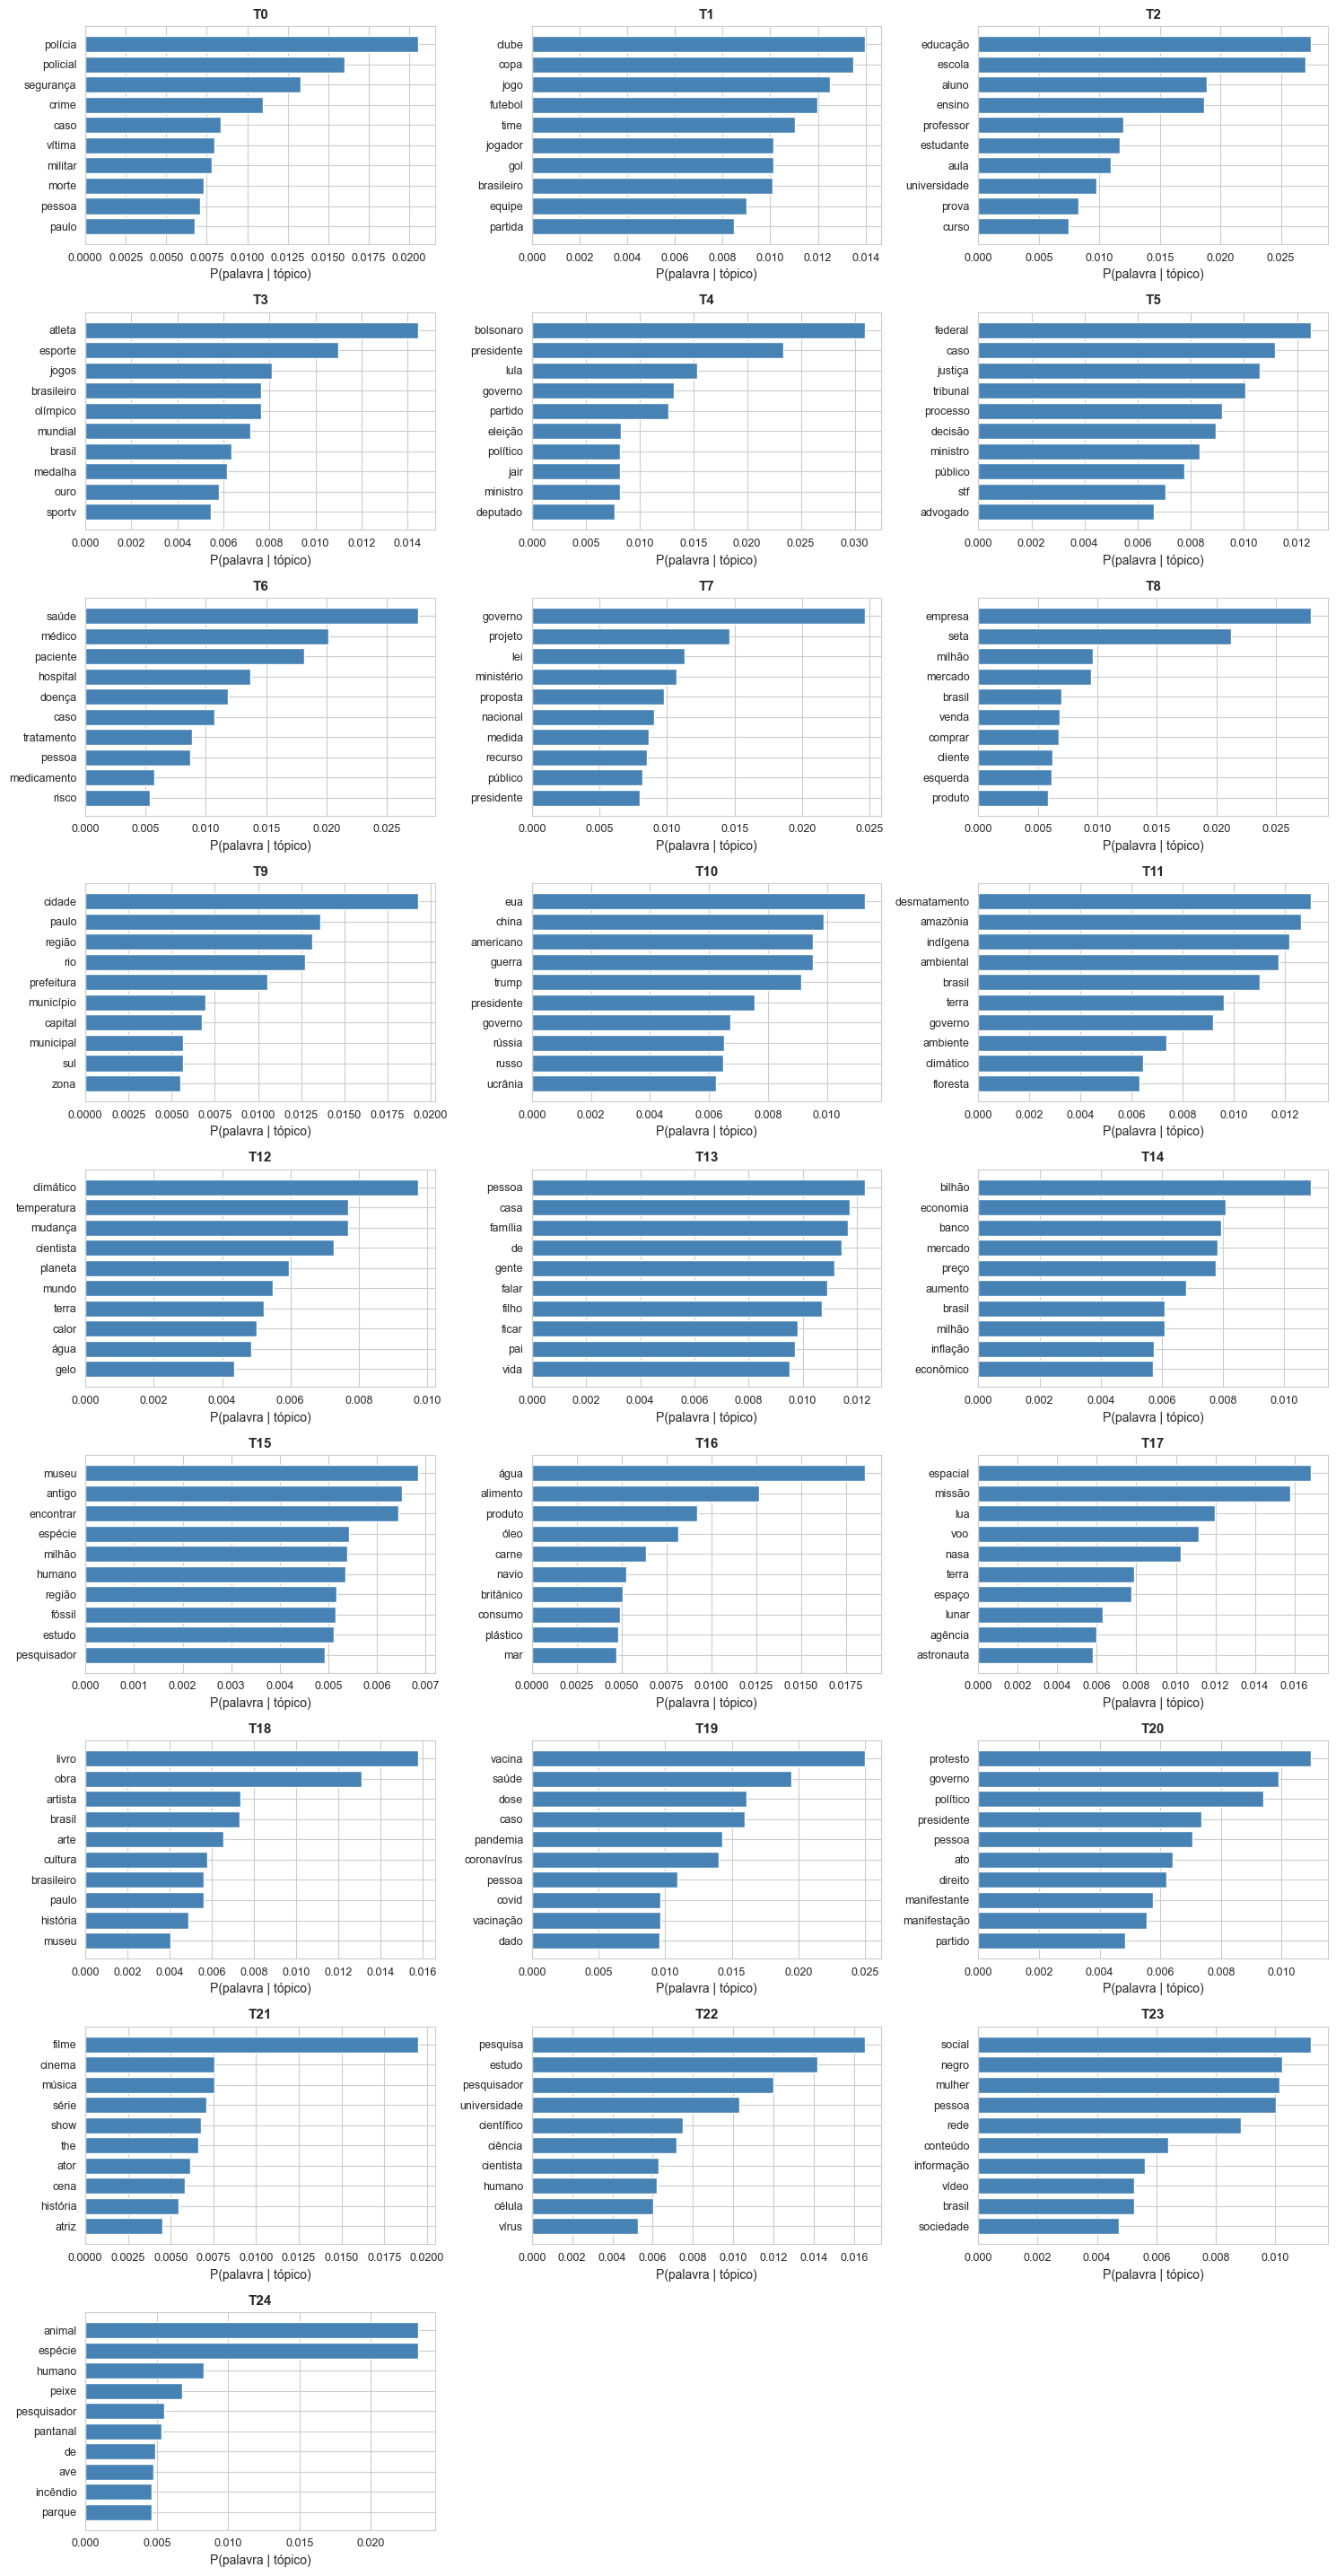

In [15]:
# Cell 14 — Bar chart top-10 keywords per topic
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
axes = axes.flatten() if BEST_K > 1 else [axes]

for tid in sorted(topics_keywords):
    word_probs = beta_df.loc[tid].nlargest(10)
    words, probs = list(word_probs.index), list(word_probs.values)
    axes[tid].barh(list(words)[::-1], list(probs)[::-1], color="steelblue")
    axes[tid].set_title(f"T{tid}", fontsize=11, fontweight="bold")
    axes[tid].set_xlabel("P(palavra | tópico)")
    axes[tid].tick_params(labelsize=9)

for i in range(BEST_K, len(axes)):
    axes[i].axis("off")

plt.tight_layout(); plt.show()


## Similaridade e redundância entre tópicos

O STM não penaliza sobreposição de vocabulário entre tópicos (ao contrário do
LDA, que tem prior Dirichlet). Dois diagnósticos visuais:

- **Similaridade cosseno** entre as linhas de `φ` (tópico×vocabulário) — pares
  com similaridade alta são candidatos a merge ou a K menor.
- **Termite plot** — peso de cada termo (união dos top termos) em cada tópico,
  num único quadro.

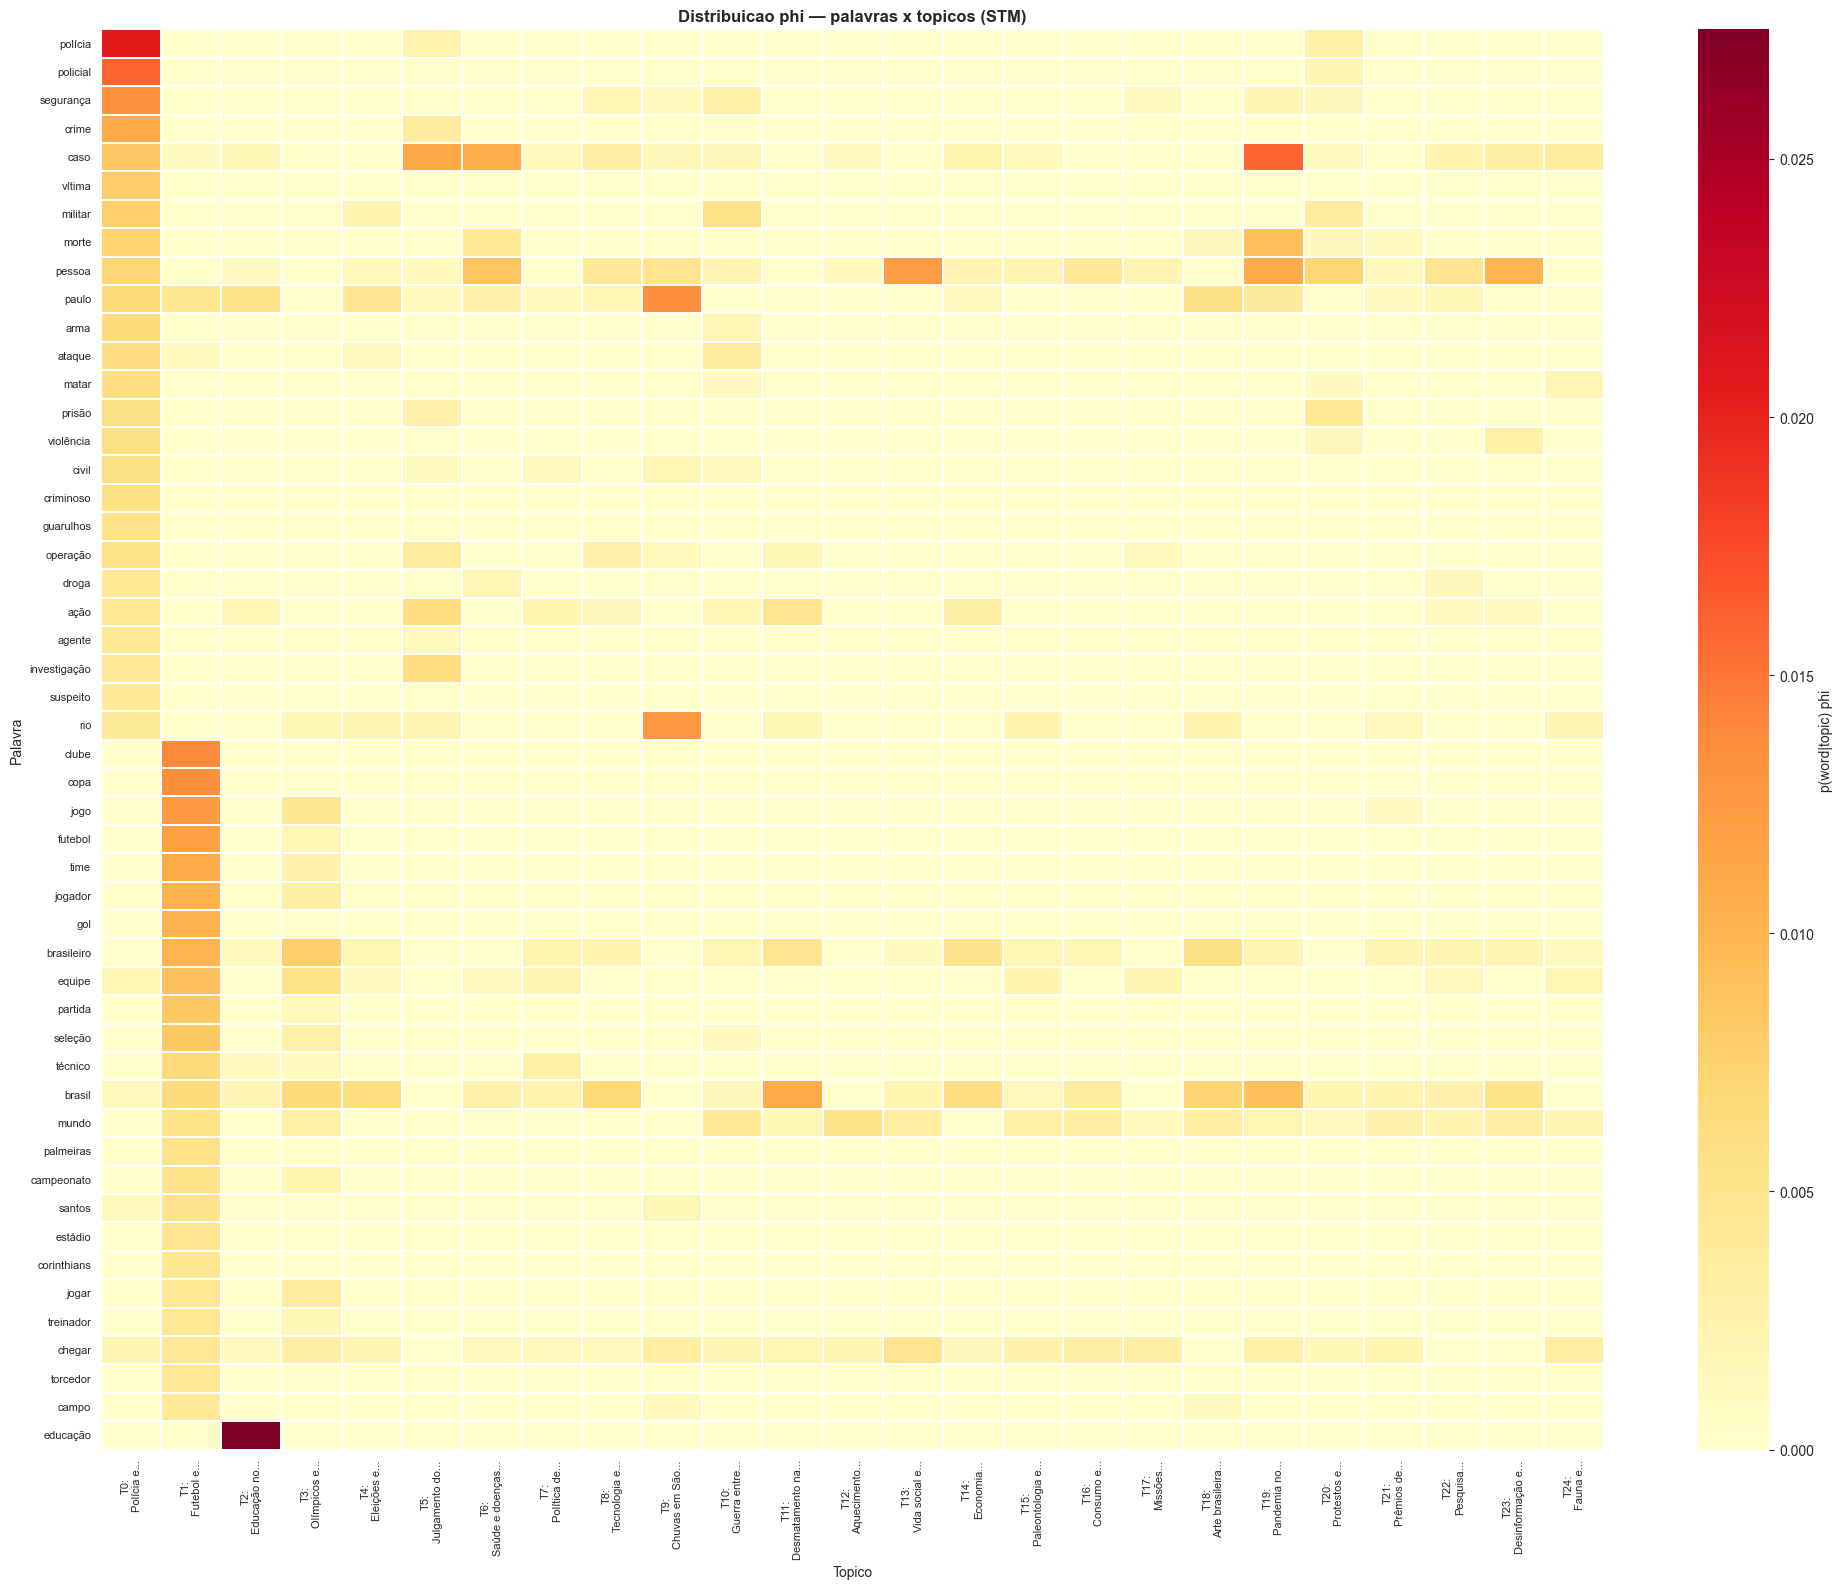

Salvo: ..\data\output\folha\stm\folha_20260724_215748\stm_heatmap_phi.png


In [16]:
# Heatmap phi: top palavras x topicos (mesmo formato do LDA — 02_lda_folha.ipynb)
import seaborn as sns
_top_n_phi = 25
_all_words = []
for tid in range(BEST_K):
    for w, _ in beta_df.loc[tid].nlargest(_top_n_phi).items():
        if w not in _all_words:
            _all_words.append(w)
_all_words = _all_words[:min(50, len(_all_words))]

_phi_hm = np.zeros((len(_all_words), BEST_K))
for tid in range(BEST_K):
    _td = beta_df.loc[tid].nlargest(200).to_dict()
    for wi, w in enumerate(_all_words):
        _phi_hm[wi, tid] = _td.get(w, 0.0)

import textwrap as _tw_phi
_col_labels = [f"T{t}:\n{_tw_phi.shorten(str(names.get(t, '')), 18, placeholder='...')}" for t in range(BEST_K)]
_phi_hm_df = pd.DataFrame(_phi_hm, index=_all_words, columns=_col_labels)

fig, ax = plt.subplots(figsize=(max(10, BEST_K * 0.8), max(8, len(_all_words) * 0.32)))
sns.heatmap(_phi_hm_df, cmap="YlOrRd", ax=ax, linewidths=0.15,
            cbar_kws={"label": "p(word|topic) phi"})
ax.set_title("Distribuicao phi — palavras x topicos (STM)", fontsize=12, fontweight="bold")
ax.set_xlabel("Topico"); ax.set_ylabel("Palavra")
plt.xticks(fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stm_heatmap_phi.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'stm_heatmap_phi.png'}")

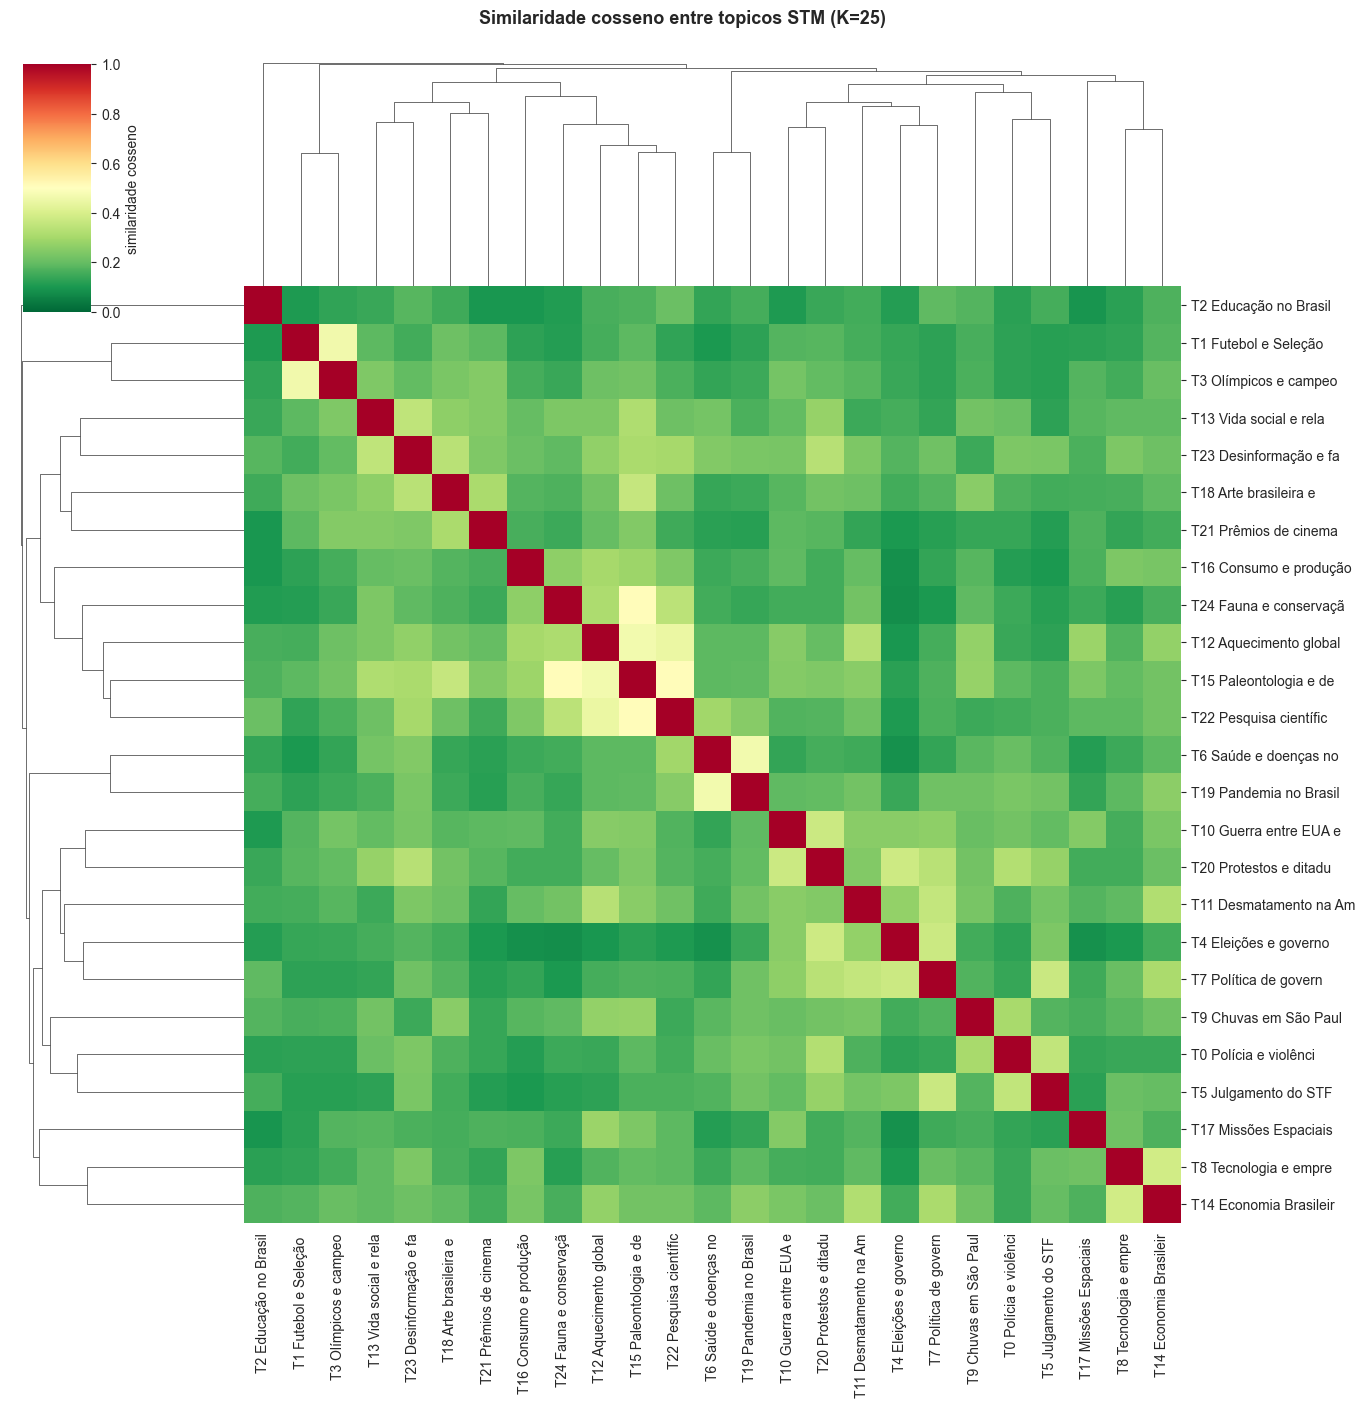

Top 5 pares de topicos mais similares (candidatos a redundancia):
  T15 <-> T24: cos=0.511  [Paleontologia e descobertas de | Fauna e conservação na Pantana]
  T15 <-> T22: cos=0.508  [Paleontologia e descobertas de | Pesquisa científica e desenvol]
  T6 <-> T19: cos=0.468  [Saúde e doenças no Brasil | Pandemia no Brasil e dados da ]
  T12 <-> T15: cos=0.466  [Aquecimento global e degelo po | Paleontologia e descobertas de]
  T1 <-> T3: cos=0.463  [Futebol e Seleção Brasileira | Olímpicos e campeonatos mundia]


In [17]:
# Similaridade cosseno entre topicos (candidatos a redundancia/merge)
from scipy.spatial.distance import squareform, pdist

_phi_sim = beta_df.values  # (K, vocab_size)
_sim = 1 - squareform(pdist(_phi_sim, metric="cosine"))
_sim_labels = [f"T{tid} {names[tid][:18]}" for tid in range(BEST_K)]
_sim_df = pd.DataFrame(_sim, index=_sim_labels, columns=_sim_labels)

g = sns.clustermap(_sim_df, cmap="RdYlGn_r", vmin=0, vmax=1,
                    figsize=(max(8, BEST_K * 0.55), max(8, BEST_K * 0.55)),
                    annot=BEST_K <= 15, fmt=".2f", cbar_kws={"label": "similaridade cosseno"})
g.fig.suptitle(f"Similaridade cosseno entre topicos STM (K={BEST_K})", y=1.02, fontsize=13, fontweight="bold")
g.savefig(OUTPUT_DIR / "stm_topic_similarity.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

_iu = np.triu_indices_from(_sim, k=1)
_pairs = sorted(zip(_sim[_iu], zip(_iu[0], _iu[1])), reverse=True)[:5]
print("Top 5 pares de topicos mais similares (candidatos a redundancia):")
for score, (i, j) in _pairs:
    print(f"  T{i} <-> T{j}: cos={score:.3f}  [{names[i][:30]} | {names[j][:30]}]")

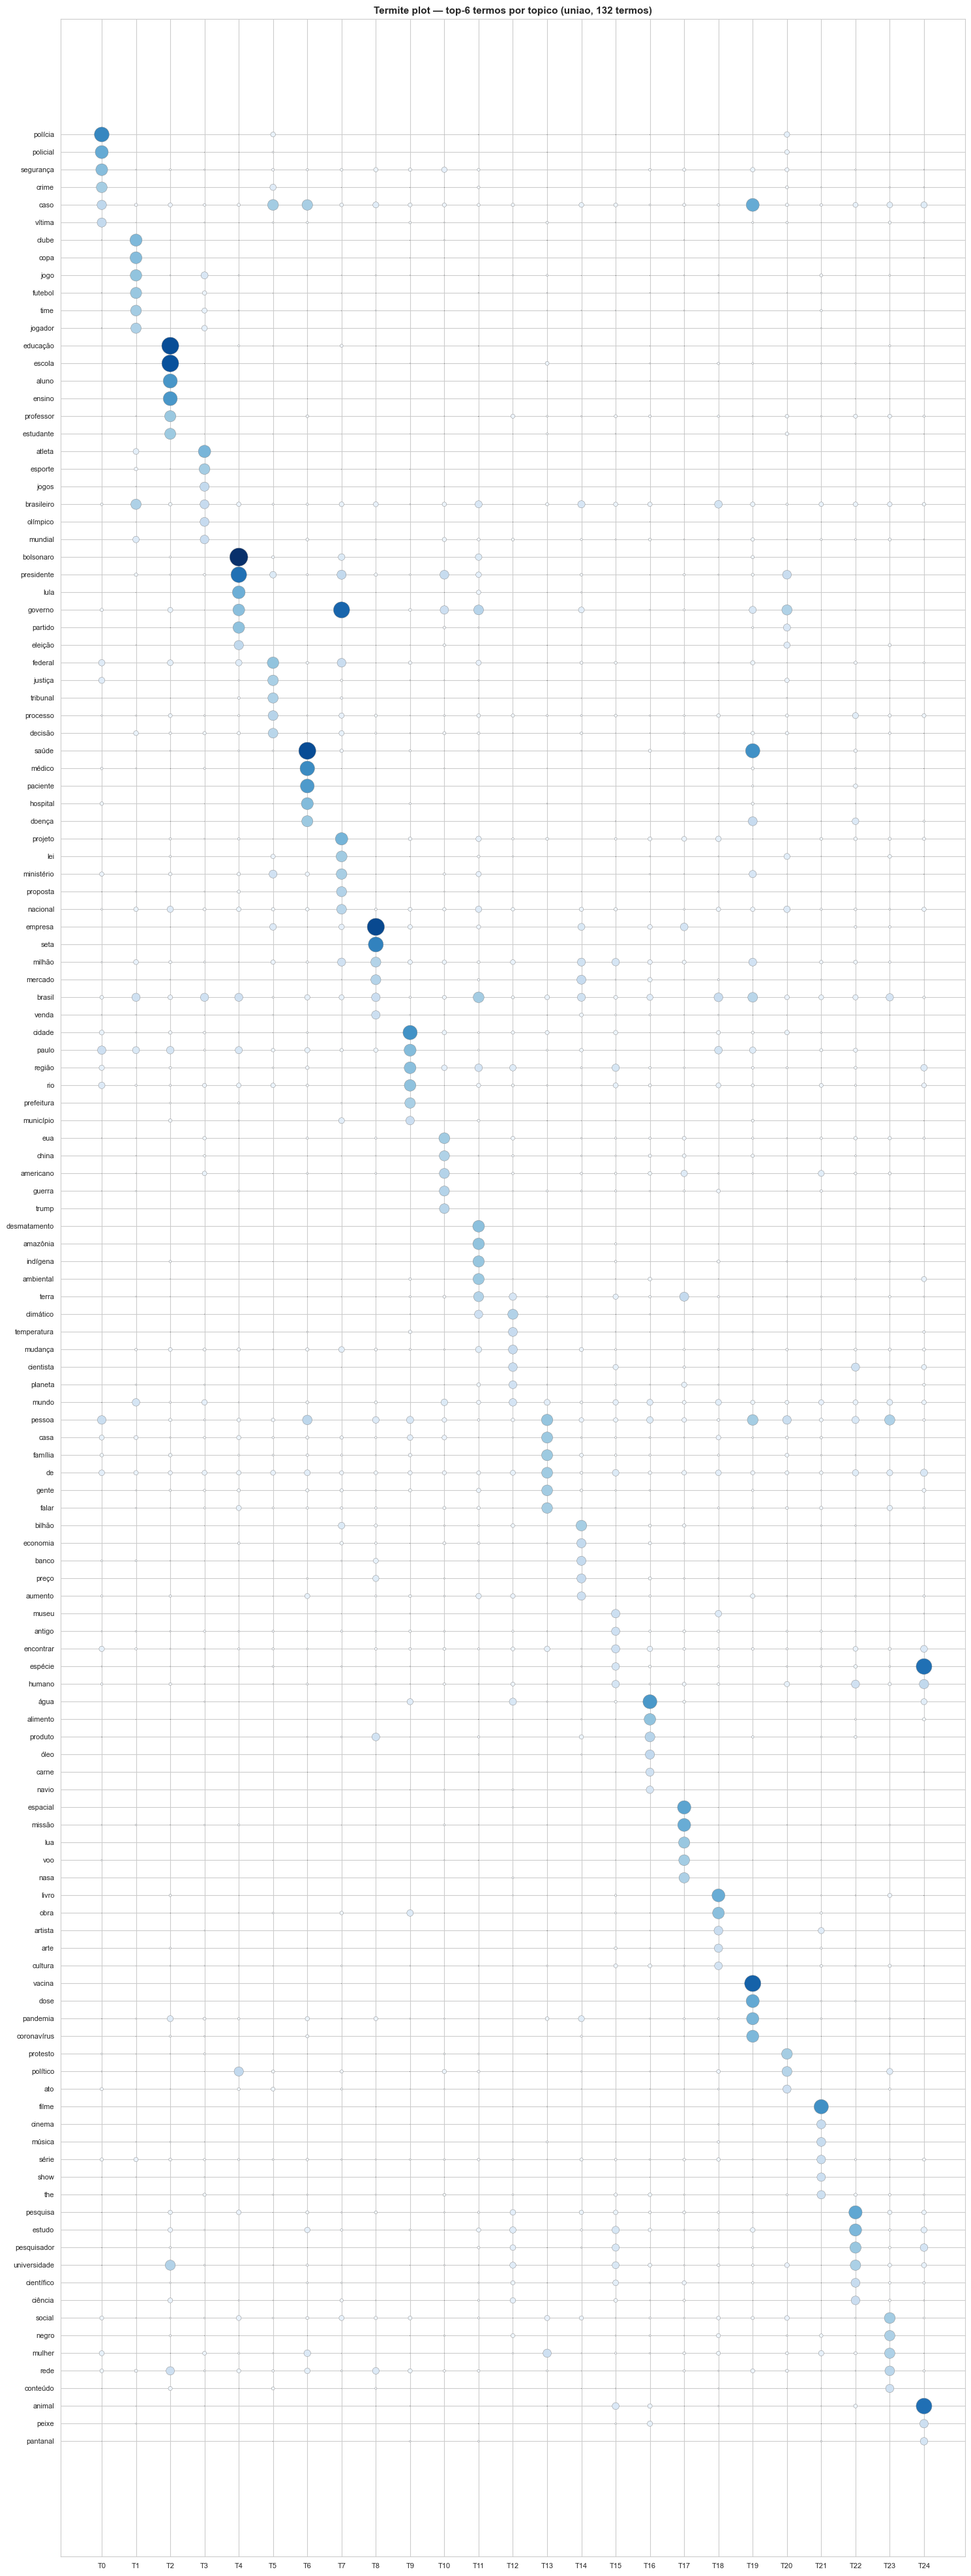

In [18]:
# Termite plot: peso topico x termo (uniao dos top termos por topico)
_TERMITE_TOPN = 6
_term_union, _seen_terms = [], set()
for tid in sorted(topics_keywords):
    for w in topics_keywords[tid][:_TERMITE_TOPN]:
        if w not in _seen_terms:
            _seen_terms.add(w)
            _term_union.append(w)

_phi_term = beta_df.values  # (K, vocab_size)
_vocab_idx_term = {w: i for i, w in enumerate(beta_df.columns)}
_termite = pd.DataFrame(
    {f"T{tid}": [_phi_term[tid, _vocab_idx_term[w]] if w in _vocab_idx_term else 0.0 for w in _term_union]
     for tid in range(BEST_K)},
    index=_term_union,
)

fig, ax = plt.subplots(figsize=(max(8, BEST_K * 0.6), max(6, len(_term_union) * 0.3)))
_xx, _yy = np.meshgrid(range(BEST_K), range(len(_term_union)))
_sizes = _termite.values / _termite.values.max() * 400
ax.scatter(_xx.flatten(), _yy.flatten(), s=_sizes.flatten(), c=_sizes.flatten(),
           cmap="Blues", edgecolors="gray", linewidths=0.3)
ax.set_xticks(range(BEST_K)); ax.set_xticklabels([f"T{t}" for t in range(BEST_K)], fontsize=8)
ax.set_yticks(range(len(_term_union))); ax.set_yticklabels(_term_union, fontsize=8)
ax.set_title(f"Termite plot — top-{_TERMITE_TOPN} termos por topico (uniao, {len(_term_union)} termos)",
             fontsize=11, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 9. Métricas quantitativas

- **c_v** recomputada (validação cruzada do grid)
- **Exclusivity**: 1 - prop. de keywords compartilhadas entre tópicos
- **Topic Diversity**: razão de palavras únicas no consolidado dos top-K
- **Diversity entropy** das distribuições θ doc-tópico (quão espalhadas)


Calculando métricas...


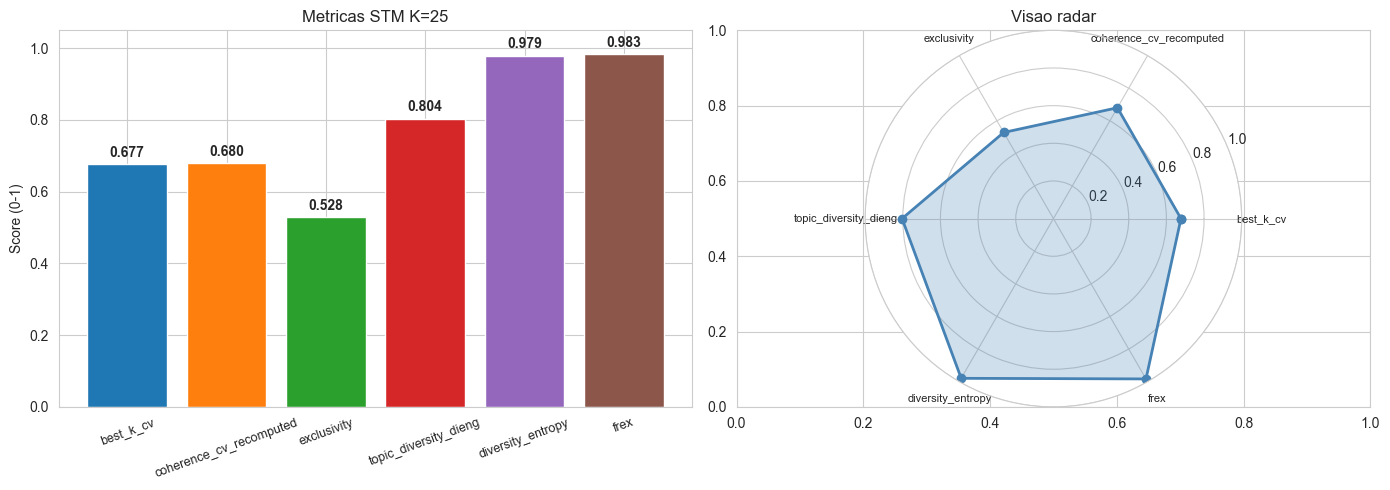

{
  "model": "stm",
  "topic_type": "probabilistic",
  "granularity": "unit",
  "corpus": "folha",
  "corpus_version": "folha_20260628_185652",
  "n_topics": 25,
  "best_k_cv": 0.6774544080017959,
  "exclusivity": 0.528310031353579,
  "diversity_entropy": 0.9793719544715688,
  "topic_diversity_dieng": 0.804,
  "frex": 0.9831173148109617,
  "sigma_prior": 0.7,
  "gamma_prior": "L1",
  "em_iterations": 92,
  "coherence_cv_recomputed": 0.6798853878913887
}


In [19]:
# Cell 16 — Calcula metricas
print("Calculando métricas...")

# FREX/exclusividade — beta do STM (K x vocab_R, exp(logbeta)) faz o papel do get_topics()
_phi = beta_df.values
_vocab_idx = {w: i for i, w in enumerate(beta_df.columns)}
_topic_idx = {tid: tid for tid in range(BEST_K)}
_top_n_metrics = params["evaluation"].get("top_n_keywords_metrics", 20)
frex_mean, frex_per_topic = compute_frex_score(
    topics_keywords, _phi, _vocab_idx, _topic_idx, top_n=_top_n_metrics,
)

# Exclusividade c-TF-IDF (MESMA metrica do LDA/NMF/BERTopic)
_topic_word_scores_stm = {
    tid: {beta_df.columns[i]: float(_phi[tid, i]) for i in range(_phi.shape[1]) if _phi[tid, i] > 1e-9}
    for tid in range(BEST_K)
}
_excl_mean, _excl_per_topic = compute_exclusivity_ctfidf(
    topics_keywords, _topic_word_scores_stm, top_n=_top_n_metrics,
)

metrics = {
    "model": "stm",
    "topic_type": "probabilistic",
    "granularity": "unit",
    "corpus": CORPUS_ID,
    "corpus_version": globals().get("CORPUS_VERSION", "n/a"),
    "n_topics": BEST_K,
    "best_k_cv": float(scores.get(BEST_K, 0.0)),
    "exclusivity": float(_excl_mean),
    "diversity_entropy": float(compute_diversity(full)),
    "topic_diversity_dieng": float(compute_topic_diversity(topics_keywords)),
    "frex": float(frex_mean),
    "sigma_prior": best_sigma,
    "gamma_prior": best_gamma,
    "em_iterations": stm_meta["iterations"],
}
# C_v recomputado filtrando palavras fora do Dictionary (vocab R != gensim em bordas)
metrics["coherence_cv_recomputed"] = float(compute_coherence_cv(
    {t: [w for w in ws if w in dictionary.token2id] for t, ws in topics_keywords.items()},
    tokenized, dictionary,
))

# Visualiza num radar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_keys = ["best_k_cv", "coherence_cv_recomputed", "exclusivity",
               "topic_diversity_dieng", "diversity_entropy", "frex"]
metric_vals = [metrics[k] for k in metric_keys]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
axes[0].bar(metric_keys, metric_vals, color=colors)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("Score (0-1)")
axes[0].set_title(f"Metricas STM K={BEST_K}")
axes[0].tick_params(axis="x", rotation=20, labelsize=9)
for i, (k, v) in enumerate(zip(metric_keys, metric_vals)):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

angles = np.linspace(0, 2*np.pi, len(metric_keys), endpoint=False).tolist()
vals = metric_vals + [metric_vals[0]]
angles_p = angles + [angles[0]]
axes[1] = plt.subplot(122, projection="polar")
axes[1].plot(angles_p, vals, "o-", linewidth=2, color="steelblue")
axes[1].fill(angles_p, vals, alpha=0.25, color="steelblue")
axes[1].set_xticks(angles); axes[1].set_xticklabels(metric_keys, fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].set_title("Visao radar")

plt.tight_layout(); plt.show()
print(json.dumps(metrics, indent=2))


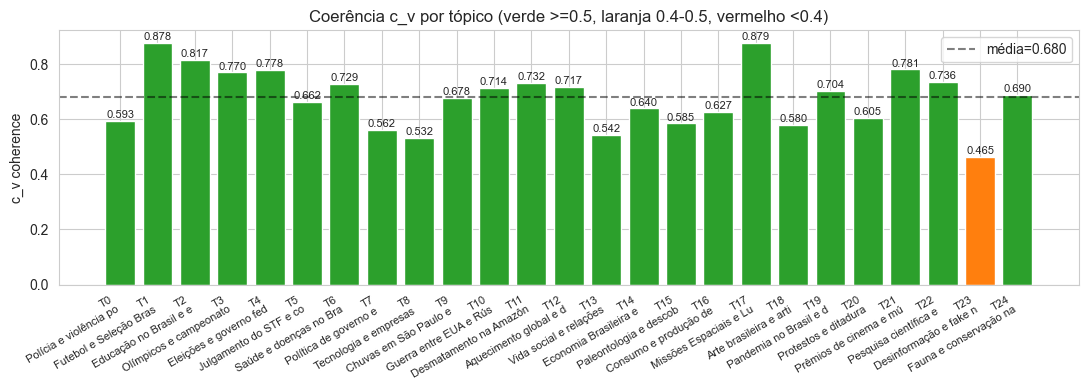

In [20]:
# Cell 17 — c_v por topico (nao so media)
from gensim.models import CoherenceModel
cm = CoherenceModel(
    topics=[[w for w in topics_keywords[tid] if w in dictionary.token2id] for tid in sorted(topics_keywords)],
    texts=tokenized, dictionary=dictionary, coherence="c_v",
)
per_topic_cv = cm.get_coherence_per_topic()

fig, ax = plt.subplots(figsize=(11, 4))
tids = sorted(topics_keywords)
labels = [f"T{tid}\n{names[tid][:22]}" for tid in tids]
bars = ax.bar(tids, per_topic_cv, color=["#2ca02c" if c >= 0.5 else "#ff7f0e" if c >= 0.4 else "#d62728" for c in per_topic_cv])
ax.axhline(np.mean(per_topic_cv), color="black", linestyle="--", alpha=0.5, label=f"média={np.mean(per_topic_cv):.3f}")
ax.set_xticks(tids); ax.set_xticklabels(labels, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("c_v coherence"); ax.set_title("Coerência c_v por tópico (verde >=0.5, laranja 0.4-0.5, vermelho <0.4)")
ax.legend()
for bar, c in zip(bars, per_topic_cv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{c:.3f}",
            ha="center", fontsize=8)
plt.tight_layout(); plt.show()


In [21]:
# Estabilidade multi-seed: N/A para o STM — init.type="Spectral" é
# determinístico (mesmo resultado para qualquer seed; Roberts et al. 2016).
# A robustez do STM é coberta pelo heldout likelihood do grid K (diagnostics).
print("Estabilidade multi-seed: N/A para STM (Spectral init determinístico).")
results_per_seed = {}


Estabilidade multi-seed: N/A para STM (Spectral init determinístico).


## 10. Distribuição de documentos por tópico

Mostra balanceamento dos clusters. Distribuição muito desigual pode indicar:
- 1 tópico "lixo" capturando outliers
- K muito alto fragmentando o sinal


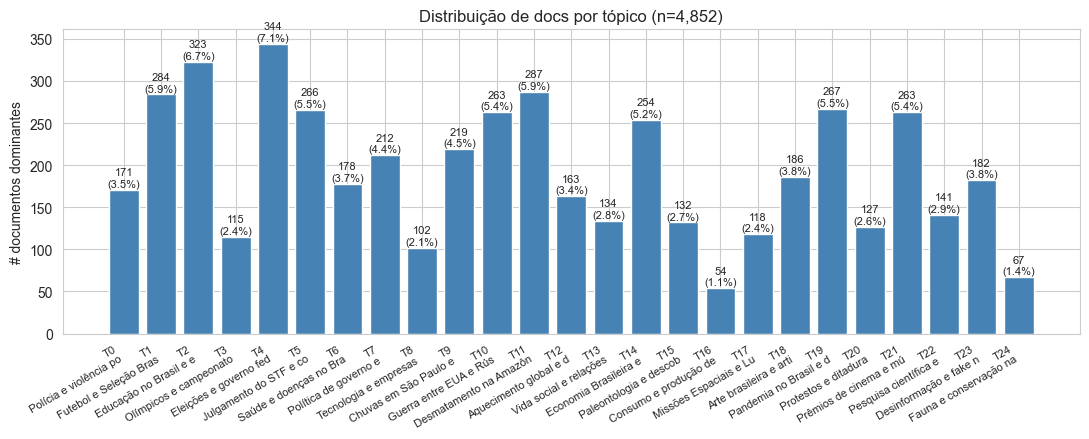


Docs por tópico — descritivas: {'count': 25.0, 'mean': 194.08, 'std': 79.9426461074855, 'min': 54.0, '25%': 132.0, '50%': 182.0, '75%': 263.0, 'max': 344.0}


In [22]:
# Cell 18 — Bar chart docs por topico
topic_doc_counts = pd.Series(dominant).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4.5))
labels = [f"T{tid}\n{names[tid][:22]}" for tid in topic_doc_counts.index]
bars = ax.bar(topic_doc_counts.index, topic_doc_counts.values, color="steelblue")
ax.set_xticks(topic_doc_counts.index); ax.set_xticklabels(labels, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("# documentos dominantes")
ax.set_title(f"Distribuição de docs por tópico (n={len(docs):,})")
for bar, c in zip(bars, topic_doc_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, c + max(topic_doc_counts)*0.01,
            f"{c:,}\n({c/len(docs)*100:.1f}%)", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

print(f"\nDocs por tópico — descritivas: {topic_doc_counts.describe().to_dict()}")


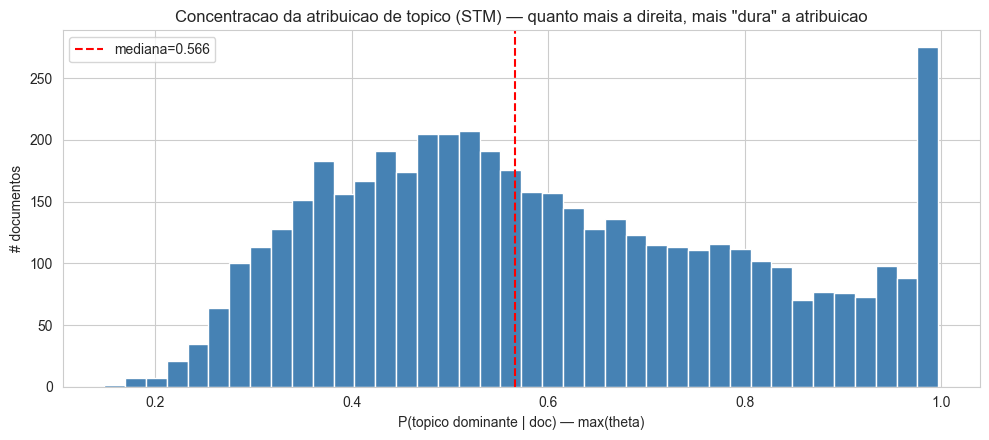

max(theta) — media=0.598, mediana=0.566, % docs com max(theta) < 0.3 (atribuicao difusa): 5.4%


In [23]:
# Histograma da probabilidade do topico dominante (dureza da atribuicao STM)
_theta_full = np.array(full)
_max_prob = _theta_full.max(axis=1)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(_max_prob, bins=40, color="steelblue", edgecolor="white")
ax.axvline(np.median(_max_prob), color="red", linestyle="--",
           label=f"mediana={np.median(_max_prob):.3f}")
ax.set_xlabel("P(topico dominante | doc) — max(theta)"); ax.set_ylabel("# documentos")
ax.set_title("Concentracao da atribuicao de topico (STM) — quanto mais a direita, mais \"dura\" a atribuicao")
ax.legend()
plt.tight_layout(); plt.show()

print(f"max(theta) — media={_max_prob.mean():.3f}, mediana={np.median(_max_prob):.3f}, "
      f"% docs com max(theta) < 0.3 (atribuicao difusa): {(_max_prob < 0.3).mean()*100:.1f}%")

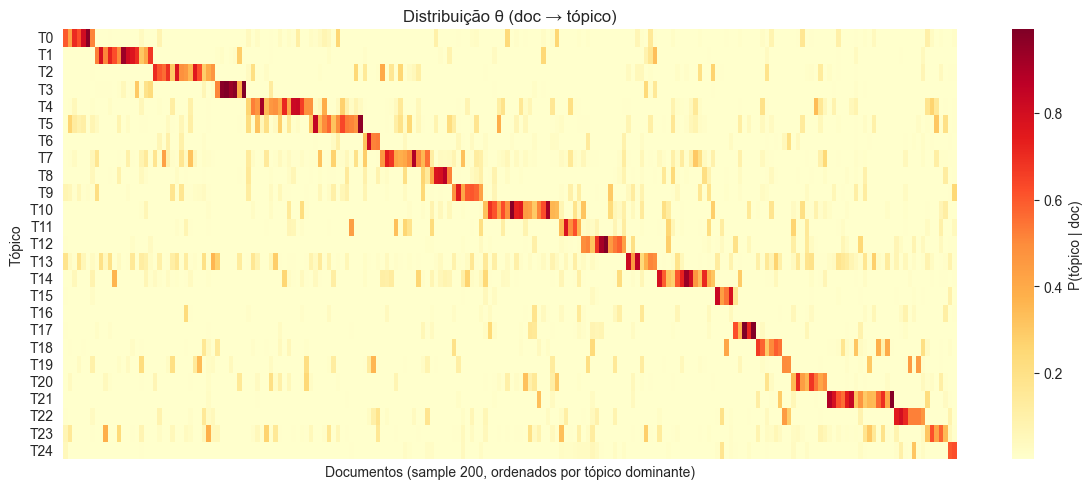

In [24]:
# Cell 19 — Heatmap theta (doc x topico) — sample
sample_n = min(200, len(full))
sample_idx = np.random.RandomState(42).choice(len(full), sample_n, replace=False)
theta_sample = np.array([full[i] for i in sample_idx])

# Sort sample by dominant topic for readability
sample_dom = theta_sample.argmax(axis=1)
order = np.argsort(sample_dom)
theta_sorted = theta_sample[order]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(theta_sorted.T, cmap="YlOrRd", cbar_kws={"label": "P(tópico | doc)"},
            xticklabels=False, yticklabels=[f"T{i}" for i in range(BEST_K)], ax=ax)
ax.set_xlabel(f"Documentos (sample {sample_n}, ordenados por tópico dominante)")
ax.set_ylabel("Tópico"); ax.set_title("Distribuição θ (doc → tópico)")
plt.tight_layout(); plt.show()


## t-SNE do espaço de tópicos (θ)

Reduz a matriz θ (N×K) a 2D via t-SNE. Gera PNG colorido por tópico dominante e versão HTML interativa com hover do texto.


Calculando t-SNE sobre matriz theta...


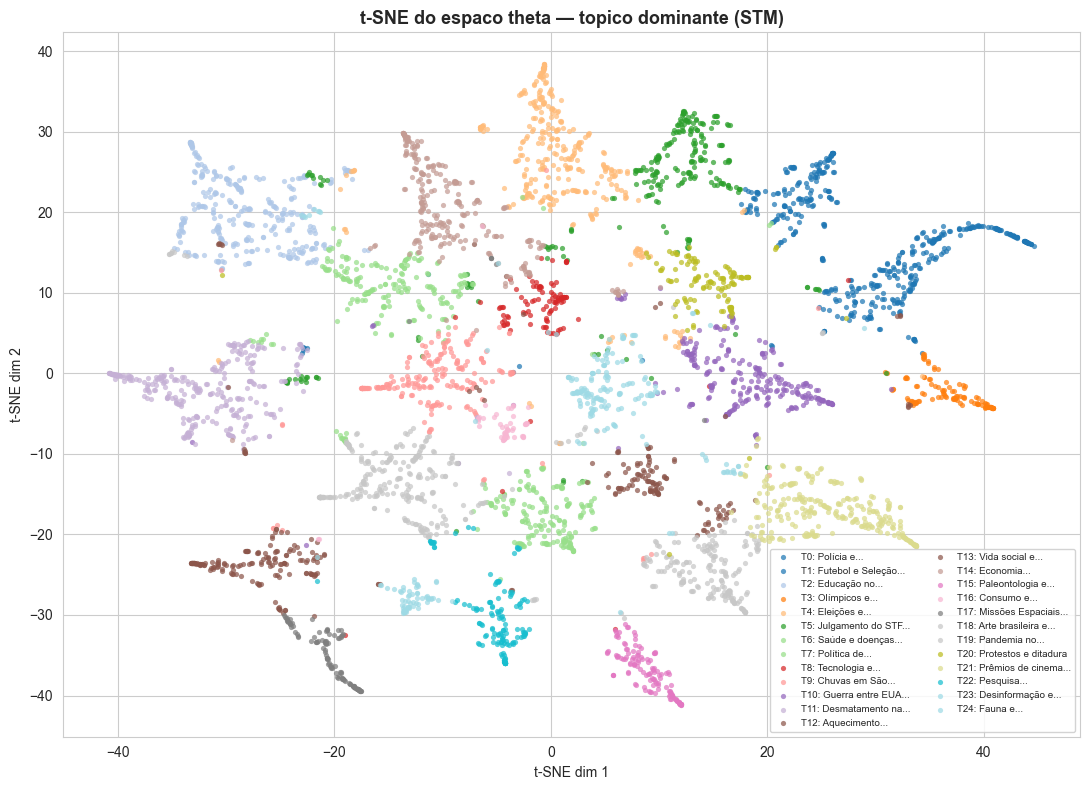

Salvo: ..\data\output\folha\stm\folha_20260724_215748\stm_tsne_theta_topico.png


Salvo: ..\data\output\folha\stm\folha_20260724_215748\stm_tsne_theta_interactive.html


In [25]:
import plotly.express as px
from sklearn.manifold import TSNE

_theta_mat = np.array(full)  # (n_docs, K)
_texts_stm = [t[:100] + "..." if len(t) > 100 else t for t in docs]

print("Calculando t-SNE sobre matriz theta...")
_tsne = TSNE(n_components=2, perplexity=30, random_state=seed, max_iter=500)
_theta_2d = _tsne.fit_transform(_theta_mat)

_cmap_stm = plt.get_cmap("tab20", max(BEST_K, 1))

# PNG por topico dominante
fig, ax = plt.subplots(figsize=(11, 8))
for tid in range(BEST_K):
    _mm = np.array(dominant) == tid
    if _mm.any():
        import textwrap as _tw_u
        _nm = _tw_u.shorten(str(names.get(tid, "")), 20, placeholder="...")
        ax.scatter(_theta_2d[_mm, 0], _theta_2d[_mm, 1],
                   c=[_cmap_stm(tid)], s=14, alpha=0.72, linewidths=0,
                   label=f"T{tid}: {_nm}")
ax.set_title("t-SNE do espaco theta — topico dominante (STM)", fontsize=13, fontweight="bold")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.legend(loc="best", fontsize=7, framealpha=0.85, ncol=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stm_tsne_theta_topico.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'stm_tsne_theta_topico.png'}")

# HTML interativo por topico dominante
import textwrap as _tw_u2
_tsne_df_stm = pd.DataFrame({
    "x": _theta_2d[:, 0], "y": _theta_2d[:, 1],
    "Texto": _texts_stm,
    "Topico": [f"T{t}: {_tw_u2.shorten(str(names.get(t,"")), 25, placeholder="...")}" for t in dominant],
})
fig_u = px.scatter(
    _tsne_df_stm, x="x", y="y", color="Topico",
    hover_data={"x": False, "y": False, "Texto": True},
    title="t-SNE espaco theta — topico dominante (interativo, STM)",
    labels={"x": "t-SNE dim 1", "y": "t-SNE dim 2"}, opacity=0.72,
)
fig_u.update_traces(marker_size=5)
_out_u = OUTPUT_DIR / "stm_tsne_theta_interactive.html"
fig_u.write_html(_out_u)
fig_u.show()
print(f"Salvo: {_out_u}")


## 11. Cross-tab tópico × categoria Folha

Folha tem categorias editoriais (ex: `politica`, `economia`, `esporte`, `mundo`).
Concentração de um tópico em uma categoria valida coerência semântica.



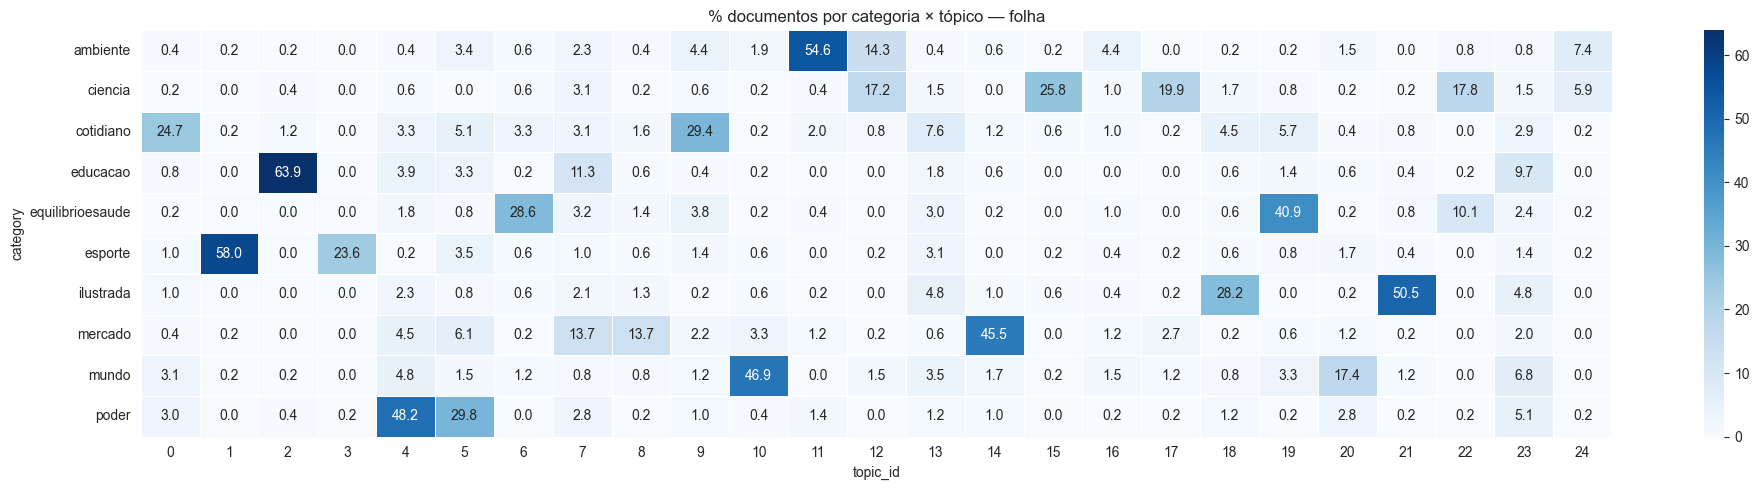

In [26]:
# Heatmap tópico × categoria — folha
if 'category' in df.columns:
    df_topic = df[['category']].copy()
    df_topic['topic_id'] = dominant
    df_topic = df_topic[df_topic['topic_id'] != -1]
    pivot = df_topic.groupby(['category', 'topic_id']).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    import seaborn as sns
    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns)*0.8), max(4, len(pivot)*0.5)))
    sns.heatmap(pivot_pct.round(1), annot=True, fmt='.1f', cmap='Blues',
                linewidths=0.5, ax=ax)
    ax.set_title('% documentos por categoria × tópico — folha')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'stm_topic_category.png', dpi=150)
    plt.show()
else:
    print('Coluna category nao encontrada')



## Evolução temporal dos tópicos

Participação média (θ) de cada tópico por mês, usando a coluna `date` do
corpus — mostra picos e declive de cada tema ao longo da janela 2018-2024.

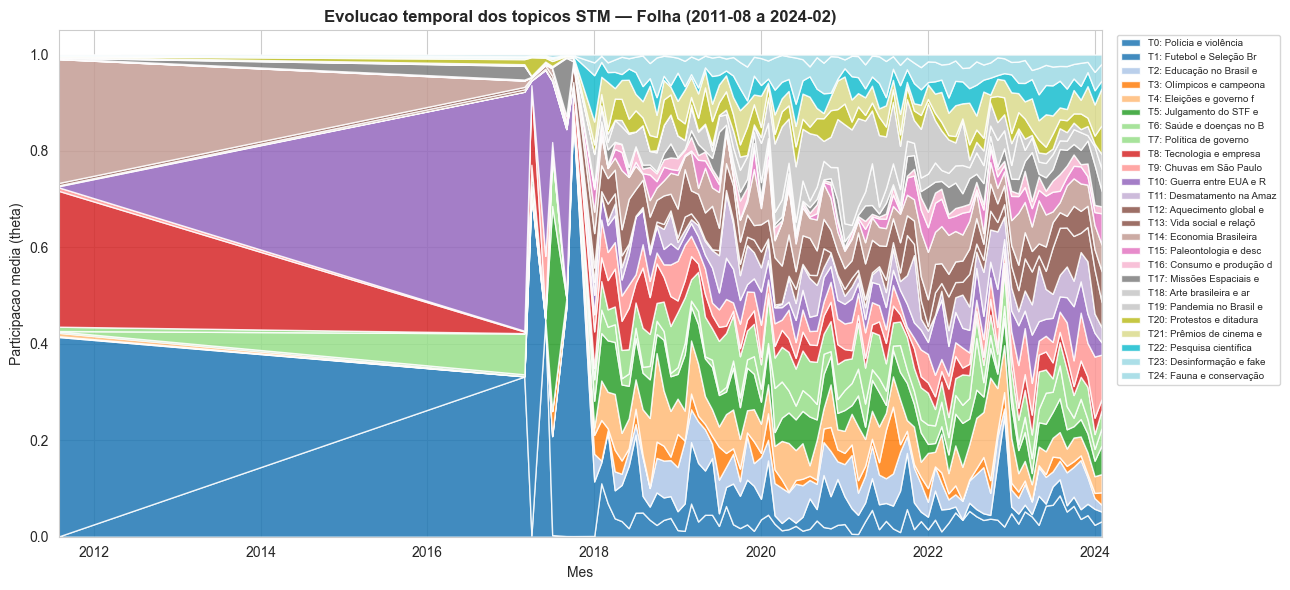

Salvo: ..\data\output\folha\stm\folha_20260724_215748\stm_topics_over_time.png


In [27]:
# Evolucao temporal dos topicos (coluna de data do corpus = cfg date_column)
# Em df a coluna mantem o nome original (ex. 'data'); so stm_df tem 'date' (renomeada no prepare_stm_input)
_date_col = cfg.get("date_column", "data")
_df_time = (df[[_date_col]].rename(columns={_date_col: "date"}).copy()
            if _date_col in df.columns else pd.DataFrame({"date": [pd.NaT] * len(df)}))
_df_time["date"] = pd.to_datetime(_df_time["date"], errors="coerce")
_theta_time = np.array(full)  # (n_docs, K), mesma ordem de df

_valid_date = _df_time["date"].notna()
if _valid_date.sum() == 0:
    print("Coluna date sem valores parseaveis — pulando evolucao temporal.")
else:
    _df_time = _df_time[_valid_date].copy()
    _theta_time = _theta_time[_valid_date.values]
    _df_time["month"] = _df_time["date"].dt.to_period("M").dt.to_timestamp()

    _theta_by_month = pd.DataFrame(_theta_time, columns=[f"T{tid}" for tid in range(BEST_K)])
    _theta_by_month["month"] = _df_time["month"].values
    _monthly_share = _theta_by_month.groupby("month").mean().sort_index()

    fig, ax = plt.subplots(figsize=(13, 6))
    _cmap_time = plt.get_cmap("tab20", max(BEST_K, 1))
    ax.stackplot(_monthly_share.index, [_monthly_share[f"T{tid}"] for tid in range(BEST_K)],
                 labels=[f"T{tid}: {names[tid][:20]}" for tid in range(BEST_K)],
                 colors=[_cmap_time(tid) for tid in range(BEST_K)], alpha=0.85)
    ax.set_xlabel("Mes"); ax.set_ylabel("Participacao media (theta)")
    ax.set_title(f"Evolucao temporal dos topicos STM — Folha "
                 f"({_monthly_share.index.min():%Y-%m} a {_monthly_share.index.max():%Y-%m})",
                 fontsize=12, fontweight="bold")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=7, ncol=1)
    ax.set_xlim(_monthly_share.index.min(), _monthly_share.index.max())
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "stm_topics_over_time.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Salvo: {OUTPUT_DIR / 'stm_topics_over_time.png'}")

## Top documentos por tópico

Mostra os 3 docs com maior probabilidade em cada tópico — verificação qualitativa direta da semântica.


In [28]:
# Cell 22 — Top 3 docs por topico
TOP_N_DOCS = 3
TRUNC = 200

theta_arr = np.array(full)
print("Top docs por topico (truncados em 200 chars):\n")
for tid in sorted(topics_keywords):
    top_idx = np.argsort(theta_arr[:, tid])[::-1][:TOP_N_DOCS]
    print(f"=== T{tid} [{names[tid]}] ===")
    print(f"  keywords: {topics_keywords[tid][:8]}\n")
    for rank, idx in enumerate(top_idx, 1):
        prob = theta_arr[idx, tid]
        cat = df.iloc[idx]["category"]
        text = df.iloc[idx]["message"][:TRUNC].replace("\n", " ")
        print(f"  #{rank} (P={prob:.3f}, cat={cat}): {text}...")
        print()


Top docs por topico (truncados em 200 chars):

=== T0 [Polícia e violência policial no Brasil] ===
  keywords: ['polícia', 'policial', 'segurança', 'crime', 'caso', 'vítima', 'militar', 'morte']

  #1 (P=0.993, cat=mercado): A Avianca Brasil, que está em recuperação judicial, devolverá oito aviões a partir da próxima segunda-feira (22).Segundo a Anac (Agência Nacional de Aviação Civil), uma aeronave percente à PK e outra ...

  #2 (P=0.992, cat=cotidiano): Duas pessoas foram mortas por policiais militares na noite de quarta-feira (23) em Santos e Guarujá, elevando para 22 o número de mortes por intervenção policial na Operação Escudo. Segundo a SSP (Sec...

  #3 (P=0.992, cat=cotidiano): Um jogador de futebol de 24 anos foi baleado na perna em meio a uma ação policial em Lauro de Freitas, na Região Metropolitana de Salvador. Alessandro Miranda Santos, conhecido como Pantico, estava be...

=== T1 [Futebol e Seleção Brasileira] ===
  keywords: ['clube', 'copa', 'jogo', 'futebol', 'time',

## Efeitos de prevalência (estimateEffect) — o diferencial do STM

Coeficientes do efeito de cada covariável sobre a prevalência esperada de cada
tópico, com IC 95% (uncertainty="Global"). Termos de spline `s(...)` são bases
não interpretáveis individualmente — a tendência temporal é lida no gráfico de
θ médio por mês abaixo.


Salvo: ..\data\output\folha\stm\folha_20260724_215748\stm_prevalence_effects.csv (500 linhas)


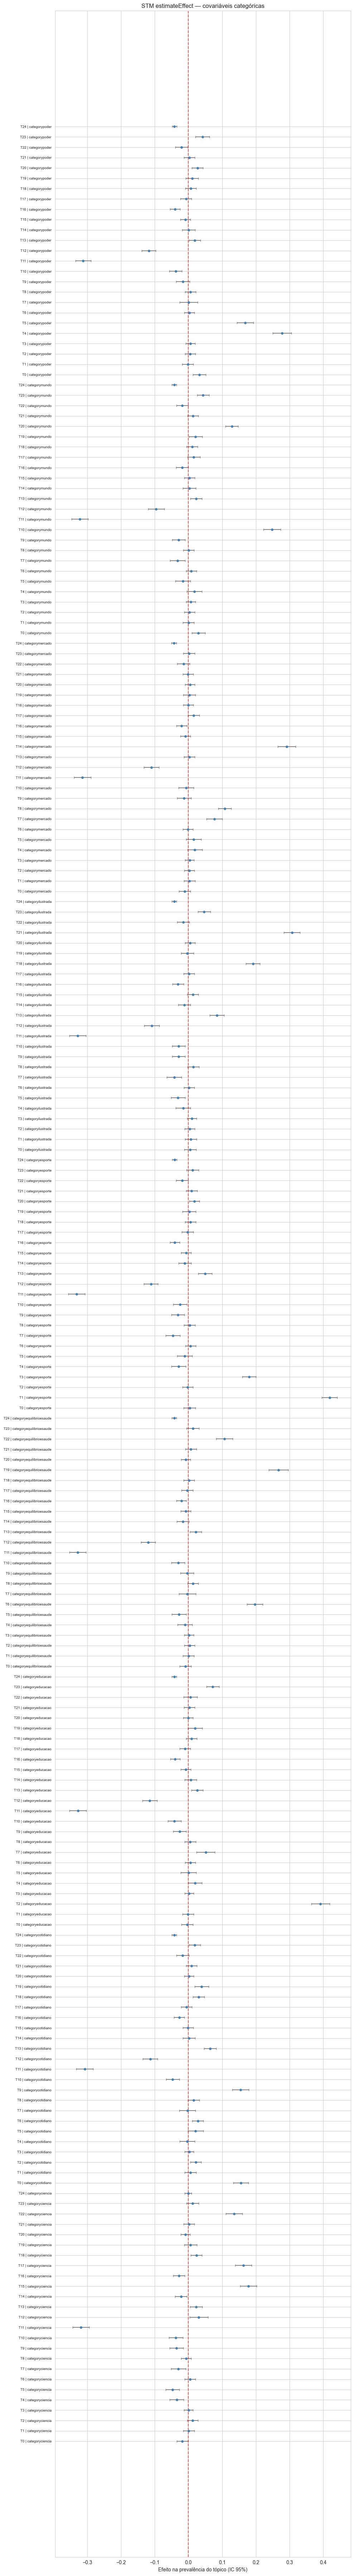

Salvo: ..\data\output\folha\stm\folha_20260724_215748\stm_prevalence_forest.png


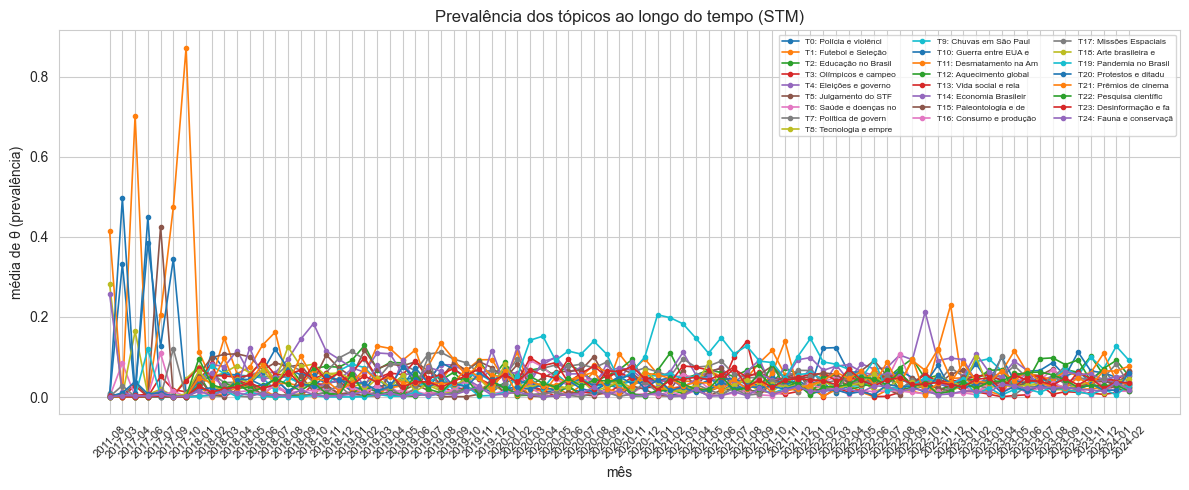

Salvo: ..\data\output\folha\stm\folha_20260724_215748\stm_prevalence_temporal.png


In [29]:
# === Efeitos de prevalência (estimateEffect) — exclusivo do STM ===
eff_rows = []
for tid, edf in effects.items():
    for _, r in edf.iterrows():
        eff_rows.append({"topic_id": tid, **r.to_dict()})
eff_df = pd.DataFrame(eff_rows)

if not eff_df.empty:
    eff_df.to_csv(OUTPUT_DIR / "stm_prevalence_effects.csv", index=False)
    print(f"Salvo: {OUTPUT_DIR / 'stm_prevalence_effects.csv'} ({len(eff_df)} linhas)")

    # Forest plot: coeficientes categóricos (exclui intercepto e bases de spline)
    _cat = eff_df[(eff_df["term"] != "(Intercept)") & (~eff_df["term"].str.startswith("s("))].copy()
    if not _cat.empty:
        _cat = _cat.sort_values(["term", "topic_id"]).reset_index(drop=True)
        fig, ax = plt.subplots(figsize=(10, max(4, 0.32 * len(_cat))))
        _ypos = list(range(len(_cat)))
        ax.errorbar(_cat["estimate"], _ypos, xerr=1.96 * _cat["std_error"],
                    fmt="o", color="steelblue", ecolor="gray", capsize=2, markersize=4)
        ax.axvline(0, color="red", linestyle="--", alpha=0.6)
        ax.set_yticks(_ypos)
        ax.set_yticklabels([f"T{int(r.topic_id)} | {r.term}" for r in _cat.itertuples()], fontsize=7)
        ax.set_xlabel("Efeito na prevalência do tópico (IC 95%)")
        ax.set_title("STM estimateEffect — covariáveis categóricas")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "stm_prevalence_forest.png", dpi=150, bbox_inches="tight", facecolor="white")
        plt.show()
        print(f"Salvo: {OUTPUT_DIR / 'stm_prevalence_forest.png'}")
else:
    print("Sem efeitos de prevalência (fórmula vazia).")

# Tendência temporal descritiva: θ médio por mês (complementa o termo de spline)
_date_col = cfg.get("date_column", "data")
if _date_col in df.columns:
    _month = pd.to_datetime(df[_date_col], errors="coerce").dt.to_period("M").astype(str)
    _tm = pd.DataFrame(theta, columns=[f"T{t}" for t in range(BEST_K)]).assign(_month=_month.values)
    _tm = _tm[_tm["_month"] != "NaT"].groupby("_month").mean()
    fig, ax = plt.subplots(figsize=(12, 5))
    for t in range(BEST_K):
        ax.plot(_tm.index, _tm[f"T{t}"], marker="o", markersize=3, linewidth=1.2,
                label=f"T{t}: {str(names.get(t, ''))[:18]}")
    ax.set_ylabel("média de θ (prevalência)"); ax.set_xlabel("mês")
    ax.set_title("Prevalência dos tópicos ao longo do tempo (STM)")
    ax.legend(fontsize=6, ncol=3)
    plt.xticks(rotation=45, fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "stm_prevalence_temporal.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Salvo: {OUTPUT_DIR / 'stm_prevalence_temporal.png'}")


## 12. Export + relatório qualitativo

Gera os CSVs canônicos (`stm_results.csv`, `stm_topics_for_eval.csv`, `stm_metrics.csv`).


In [30]:
# Cell 23 — Export final
os.makedirs(out_dir, exist_ok=True)

export_results(
    topics=dominant, probs=full, names=names, texts=docs,
    output_path=f"{out_dir}/stm_results.csv",
    topic_type="probabilistic", granularity="unit", post_ids=post_ids,
)
export_topics_for_eval(
    topics_keywords=topics_keywords, topics_names=names,
    model_name="stm", output_path=f"{out_dir}/stm_topics_for_eval.csv",
)
metrics_full = {**metrics, "k_grid_scores": json.dumps(scores),
                "prevalence_formula": PREV_FORMULA,
                "best_sigma": best_sigma, "best_gamma": best_gamma}
pd.DataFrame([metrics_full]).to_csv(f"{out_dir}/stm_metrics.csv", index=False)
# Cache acessível em próximos runs (copia pro diretório-base)
pd.DataFrame([metrics_full]).to_csv(f"{BASE_OUTPUT_DIR}/stm_metrics.csv", index=False)

# Keywords FREX do R (exclusivo do STM — palavra frequente E exclusiva do tópico)
pd.DataFrame(
    [{"topic_id": t, "topic_name": names.get(t, ""), "keywords_frex": ", ".join(ws)}
     for t, ws in keywords_frex.items()]
).to_csv(f"{out_dir}/stm_topics_frex.csv", index=False)

print(f"CSVs em {out_dir}/:")
for f in ["stm_results.csv", "stm_topics_for_eval.csv", "stm_metrics.csv", "stm_topics_frex.csv"]:
    sz = os.path.getsize(f"{out_dir}/{f}")
    print(f"  {f} ({sz/1024:.0f} KB)")


CSVs em ..\data\output\folha\stm\folha_20260724_215748/:
  stm_results.csv (26921 KB)
  stm_topics_for_eval.csv (3 KB)
  stm_metrics.csv (1 KB)
  stm_topics_frex.csv (3 KB)


In [31]:
# Cell 24 — Exclusividade + n_docs por tópico (ranking p/ o assessor de calibração)
# Espelha o bertopic_exclusividade_ranking.csv. Reusa os MESMOS topic_word_scores
# nativos (phi/beta) do cálculo de exclusividade do stm_metrics.csv, p/ o ranking
# BATER com as métricas (mesma convenção do BERTopic). Coletado pelo advisor via
# glob *exclusividade_ranking.csv.
from _helpers import export_exclusividade_ranking

excl_rank_df = export_exclusividade_ranking(
    topics_keywords=topics_keywords,
    dominant_per_doc=dominant,
    names=names,
    topic_word_scores=_topic_word_scores_stm,
    out_path=f"{out_dir}/stm_exclusividade_ranking.csv",
    top_n=params["evaluation"].get("top_n_keywords_metrics", 20),
)
print("stm_exclusividade_ranking.csv (exclusividade desc):")
print(excl_rank_df.to_string(index=False))

stm_exclusividade_ranking.csv (exclusividade desc):
 topic_id                                           topic_name  exclusividade  n_docs
       17                              Missões Espaciais e Lua       0.774292     118
        2                 Educação no Brasil e ensino superior       0.763623     323
       21            Prêmios de cinema e música hollywoodianos       0.721610     263
        1                         Futebol e Seleção Brasileira       0.716590     284
       16            Consumo e produção de alimentos no Brasil       0.713430      54
        3          Olímpicos e campeonatos mundiais de esporte       0.679229     115
       19               Pandemia no Brasil e dados da Covid-19       0.601510     267
       10                            Guerra entre EUA e Rússia       0.573844     263
        6                            Saúde e doenças no Brasil       0.553181     178
       11                   Desmatamento na Amazônia e governo       0.539876     287
  

In [32]:
# Cell 24 — Relatorio qualitativo (template)
md = qualitative_report(topics_keywords, names)
print(md)


# Qualitative report
**Total topics:** 25
## Tópicos coesos
_(preencher manualmente: tópicos com keywords semanticamente próximas e tema único)_
## Tópicos genéricos / discurso
_(preencher manualmente: keywords genéricas, sem tema concreto)_
## Tópicos lixo / boilerplate
_(preencher manualmente: keywords são fórmulas, hashtags, headers, etc.)_
## Redundâncias
_(preencher manualmente: tópicos diferentes que cobrem o mesmo tema)_
## Candidatos a stop word
_(preencher manualmente: termos repetidos em 3+ tópicos sem agregar diferenciação)_
## Tabela de tópicos
| ID | Nome | Top keywords |
|---|---|---|
| T0 | Polícia e violência policial no Brasil | polícia, policial, segurança, crime, caso, vítima, militar, morte, pessoa, paulo |
| T1 | Futebol e Seleção Brasileira | clube, copa, jogo, futebol, time, jogador, gol, brasileiro, equipe, partida |
| T2 | Educação no Brasil e ensino superior | educação, escola, aluno, ensino, professor, estudante, aula, universidade, prova, curso |
| T3 | Olím

## Próximos passos
- Comparar com LDA (`02_lda_folha.ipynb`) e BERTopic (`01_bertopic_folha.ipynb`) — triangulação LDA × STM × BERTopic
- Analisar evolução temporal de tópicos (coluna `date` disponível)

## Referências

- Lee, D. D., Seung, H. S. (1999). *Learning the parts of objects by non-negative matrix factorization*. Nature.
- Roder, M., Both, A., Hinneburg, A. (2015). *Exploring the Space of Topic Coherence Measures*. WSDM — c_v.
- Stevens, K. et al. (2012). *Exploring topic coherence over many models and many topics*. EMNLP — limitações de c_v com K alto.
- Dieng, A. B., Ruiz, F. J. R., Blei, D. M. (2020). *Topic Modeling in Embedding Spaces*. TACL — Topic Diversity.
